In [1]:
# CELL 1 — ADD NEW CELL (Imports)

import os
import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("OK — Imports loaded")
print("cv2:", cv2.__version__)


OK — Imports loaded
cv2: 4.11.0


In [2]:
# CELL 2 — FULL REPLACEMENT (Config + strict paths, no invented links)

from dataclasses import dataclass
from pathlib import Path

@dataclass
class CFG:
    # --- Your confirmed code folder (contains dmsa.json) ---
    BASE_DIR: Path = Path(r"F:\Bracu\THESIS\Final Defence\Dataset\code")

    # --- Files (must exist inside BASE_DIR unless you change the names) ---
    CSV_FILE: str = "dmsa dataset.csv"
    JSON_FILE: str = "dmsa.json"

    # --- Exact CSV columns (NEVER rename) ---
    COL_PATIENT: str = "PATIENT NAME"
    COL_LINK: str = "LINK"
    COL_COUNT: str = "Kidney COUNT"
    COL_ANATOMY: str = "ANATOMY"
    COL_POSITION: str = "POSITION"
    COL_VIEW: str = "VIEW"

    # --- Drop list (as requested) ---
    DROP_PATIENTS: tuple = (
        "MITHALI",
        "HUZAIFA",
        "HASAN AHMMED PATOARI",
        "FATEMATUZ JOHRA",
        "AFNAN",
    )

    # --- Drop 0-kidney cases from Phase-4A mask QC ---
    DROP_COUNT_ZERO: bool = True

    # --- Locked ruler ROI + locked ppcm ---
    RULER_X0: int = 240
    RULER_X1: int = 253
    RULER_Y0: int = 106
    RULER_Y1: int = 152
    PPCM_LOCKED: float = 4.2

cfg = CFG()

CSV_PATH = cfg.BASE_DIR / cfg.CSV_FILE
JSON_PATH = cfg.BASE_DIR / cfg.JSON_FILE

assert cfg.BASE_DIR.exists(), f"BASE_DIR does not exist: {cfg.BASE_DIR}"
assert CSV_PATH.exists(), f"CSV not found (expected here): {CSV_PATH}"
assert JSON_PATH.exists(), f"JSON not found (expected here): {JSON_PATH}"

print("BASE_DIR:", cfg.BASE_DIR)
print("CSV_PATH:", CSV_PATH)
print("JSON_PATH:", JSON_PATH)


BASE_DIR: F:\Bracu\THESIS\Final Defence\Dataset\code
CSV_PATH: F:\Bracu\THESIS\Final Defence\Dataset\code\dmsa dataset.csv
JSON_PATH: F:\Bracu\THESIS\Final Defence\Dataset\code\dmsa.json


In [3]:
# CELL 3 — ADD NEW CELL (Load CSV + drop requested rows safely, no column edits)

df = pd.read_csv(CSV_PATH)

# Required columns check (exact names)
need = [cfg.COL_PATIENT, cfg.COL_LINK, cfg.COL_COUNT, cfg.COL_ANATOMY, cfg.COL_POSITION]
missing = [c for c in need if c not in df.columns]
assert len(missing) == 0, f"Missing required CSV columns: {missing}"

print("Original df:", df.shape)

# Drop specific patient rows (exact match on PATIENT NAME)
drop_set = set([str(x).strip() for x in cfg.DROP_PATIENTS])
mask_drop_patient = df[cfg.COL_PATIENT].astype(str).str.strip().isin(drop_set)

# Drop Kidney COUNT == 0 rows (BRA extremely rare / out-of-scope)
if cfg.DROP_COUNT_ZERO:
    mask_drop_count0 = df[cfg.COL_COUNT].astype(int) == 0
else:
    mask_drop_count0 = np.zeros(len(df), dtype=bool)

df_use = df.loc[~(mask_drop_patient | mask_drop_count0)].copy()
df_use.reset_index(drop=True, inplace=True)

print("After drops df_use:", df_use.shape)
print("\nDropped by patient name:", int(mask_drop_patient.sum()))
print("Dropped by Kidney COUNT==0:", int(mask_drop_count0.sum()))

print("\nKidney COUNT value_counts (df_use):")
print(df_use[cfg.COL_COUNT].value_counts(dropna=False))

print("\nANATOMY value_counts (top 10, df_use):")
print(df_use[cfg.COL_ANATOMY].value_counts(dropna=False).head(10))


Original df: (2312, 25)
After drops df_use: (2285, 25)

Dropped by patient name: 27
Dropped by Kidney COUNT==0: 15

Kidney COUNT value_counts (df_use):
Kidney COUNT
2    1842
1     443
Name: count, dtype: int64

ANATOMY value_counts (top 10, df_use):
ANATOMY
NORMAL     1660
SINGLE      437
ECTOPIC     152
HORSHOE      36
Name: count, dtype: int64


In [4]:
# CELL 4 — ADD NEW CELL (Load dmsa.json + quick structure sanity)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    ann = json.load(f)

assert isinstance(ann, dict), "Expected dmsa.json top-level to be dict keyed by filename."

json_keys = list(ann.keys())
print("JSON images:", len(json_keys))
print("Example JSON key:", json_keys[0])

# Quick check: find one entry with regions and labels
example = ann[json_keys[0]]
assert "regions" in example, "Expected 'regions' field in each image entry."
print("Example entry fields:", list(example.keys()))
print("Example regions keys:", list(example["regions"].keys())[:5])

# Check a few region labels
labels_seen = set()
for k in json_keys[:50]:
    reg = ann[k].get("regions", {})
    for _, r in reg.items():
        lab = r.get("region_attributes", {}).get("label", None)
        if lab is not None:
            labels_seen.add(str(lab).strip().lower())
print("Labels seen (sample):", sorted(list(labels_seen))[:10])


JSON images: 2294
Example JSON key: SARIBA_8YRS.jpeg
Example entry fields: ['fileref', 'size', 'filename', 'base64_img_data', 'file_attributes', 'regions']
Example regions keys: ['0', '1']
Labels seen (sample): ['left', 'right']


In [5]:
# CELL 5 — FULL REPLACEMENT (STRICT image path resolver: uses LINK as-is only)

from pathlib import Path
import cv2
import numpy as np

def _basename_from_link(link_value):
    s = str(link_value).strip().replace("\\", "/")
    return Path(s).name

def resolve_image_path_from_link_strict(link_value):
    """
    STRICT MODE (no bullshit links):
    - Treat LINK as the authoritative path.
    - Do not guess folders.
    - Do not scan directories.
    - If the path does not exist, fail loudly.
    """
    s = str(link_value).strip()
    p = Path(s)

    # If LINK is relative, resolve relative to BASE_DIR (ONLY this one allowed fallback)
    if not p.is_absolute():
        p = cfg.BASE_DIR / p

    if not p.exists():
        raise FileNotFoundError(f"LINK path does not exist: {p} (original LINK='{s}')")

    return p

def load_gray_256(img_path: Path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"cv2 failed to read: {img_path}"
    assert img.shape == (256, 256), f"Expected 256x256, got {img.shape} for {img_path}"
    return img

# Build JSON key set (filename match is by basename)
json_key_set = set([str(k).strip() for k in ann.keys()])

rows = []
missing_in_json = 0
missing_image_file = 0

for i in range(len(df_use)):
    link = df_use.loc[i, cfg.COL_LINK]
    base = _basename_from_link(link)
    in_json = base in json_key_set
    if not in_json:
        missing_in_json += 1

    img_path = None
    try:
        img_path = resolve_image_path_from_link_strict(link)
        _ = load_gray_256(img_path)  # validate readable + 256x256
    except Exception:
        missing_image_file += 1

    rows.append({
        "idx": i,
        "basename": base,
        "in_json": in_json,
        "img_path": str(img_path) if img_path is not None else None,
    })

match_df = pd.DataFrame(rows)

print("Rows:", len(match_df))
print("Missing in JSON:", int(missing_in_json))
print("Missing/invalid image path:", int(missing_image_file))

print("\nExamples missing in JSON (first 10):")
print(match_df.loc[~match_df["in_json"], ["idx", "basename"]].head(10))

print("\nExamples missing image path (first 10):")
print(match_df.loc[match_df["img_path"].isna(), ["idx", "basename"]].head(10))


Rows: 2285
Missing in JSON: 0
Missing/invalid image path: 0

Examples missing in JSON (first 10):
Empty DataFrame
Columns: [idx, basename]
Index: []

Examples missing image path (first 10):
Empty DataFrame
Columns: [idx, basename]
Index: []


In [6]:
# CELL 6 — ADD NEW CELL (Polygon -> mask builder for THIS dmsa.json format)

def load_gray_256(img_path: Path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"cv2 failed to read: {img_path}"
    assert img.shape == (256, 256), f"Expected 256x256, got {img.shape} for {img_path}"
    return img

def polygons_from_via_entry(via_entry):
    """
    Returns dict: {"left":[poly...], "right":[poly...]} where poly is Nx2 int32
    VIA format uses:
      entry["regions"] = { "0": { "shape_attributes": {all_points_x/y}, "region_attributes": {"label": "left/right"} } }
    """
    out = {"left": [], "right": []}
    regs = via_entry.get("regions", {})
    for _, r in regs.items():
        lab = str(r.get("region_attributes", {}).get("label", "")).strip().lower()
        if lab not in ["left", "right"]:
            continue

        sa = r.get("shape_attributes", {})
        xs = sa.get("all_points_x", None)
        ys = sa.get("all_points_y", None)
        if xs is None or ys is None:
            continue
        if len(xs) < 3 or len(ys) < 3 or len(xs) != len(ys):
            continue

        pts = np.stack([np.array(xs), np.array(ys)], axis=1).astype(np.int32)

        # clip to image bounds (0..255)
        pts[:, 0] = np.clip(pts[:, 0], 0, 255)
        pts[:, 1] = np.clip(pts[:, 1], 0, 255)

        out[lab].append(pts)
    return out

def build_lr_mask_3class(filename):
    """
    Returns:
      mask3: uint8 (0=bg, 1=left, 2=right)
      m_left: uint8 (0/255)
      m_right: uint8 (0/255)
    """
    assert filename in ann, f"Filename not in JSON: {filename}"
    entry = ann[filename]
    polys = polygons_from_via_entry(entry)

    m_left = np.zeros((256, 256), dtype=np.uint8)
    m_right = np.zeros((256, 256), dtype=np.uint8)

    for pts in polys["left"]:
        cv2.fillPoly(m_left, [pts], 255)
    for pts in polys["right"]:
        cv2.fillPoly(m_right, [pts], 255)

    mask3 = np.zeros((256, 256), dtype=np.uint8)
    mask3[m_left > 0] = 1
    mask3[m_right > 0] = 2

    return mask3, m_left, m_right


In [7]:
# CELL 7 — ADD NEW CELL (Dataset-wide sanity: mask existence + basic coverage stats)

ok_rows = match_df["in_json"] & match_df["img_path"].notna()
ok_idx = match_df.loc[ok_rows, "idx"].tolist()

print("Usable rows for mask QC (have image + JSON):", len(ok_idx), "/", len(df_use))

# Basic coverage stats
areas = []
missing_side = {"left_missing": 0, "right_missing": 0, "both_missing": 0}

for i in ok_idx[:min(200, len(ok_idx))]:  # sample for speed
    base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
    mask3, ml, mr = build_lr_mask_3class(base)

    aL = int((ml > 0).sum())
    aR = int((mr > 0).sum())
    areas.append((aL, aR))

    if aL == 0 and aR == 0:
        missing_side["both_missing"] += 1
    elif aL == 0:
        missing_side["left_missing"] += 1
    elif aR == 0:
        missing_side["right_missing"] += 1

areas = np.array(areas) if len(areas) > 0 else np.zeros((0, 2), dtype=np.int64)

print("\nMask-side missing (sampled up to 200):", missing_side)
if len(areas) > 0:
    print("Left area px — min/median/max:", int(areas[:,0].min()), int(np.median(areas[:,0])), int(areas[:,0].max()))
    print("Right area px — min/median/max:", int(areas[:,1].min()), int(np.median(areas[:,1])), int(areas[:,1].max()))


Usable rows for mask QC (have image + JSON): 2285 / 2285

Mask-side missing (sampled up to 200): {'left_missing': 19, 'right_missing': 11, 'both_missing': 0}
Left area px — min/median/max: 0 406 1622
Right area px — min/median/max: 0 439 1274


In [8]:
# CELL 8 — ADD NEW CELL (Left/Right validation by centroid-x: flag potential swaps)

def mask_centroid_x(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    return float(xs.mean())

swap_flags = []
for i in ok_idx:
    base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
    _, ml, mr = build_lr_mask_3class(base)

    cxL = mask_centroid_x(ml)
    cxR = mask_centroid_x(mr)

    # If both exist: left centroid should be on the left side (smaller x) than right
    swapped = False
    if (cxL is not None) and (cxR is not None):
        swapped = cxL > cxR

    swap_flags.append({
        "idx": i,
        "basename": base,
        "cx_left": cxL,
        "cx_right": cxR,
        "suspect_swap": bool(swapped),
        "ANATOMY": df_use.loc[i, cfg.COL_ANATOMY],
        "POSITION": df_use.loc[i, cfg.COL_POSITION],
        "Kidney COUNT": df_use.loc[i, cfg.COL_COUNT],
        "PATIENT NAME": df_use.loc[i, cfg.COL_PATIENT],
        "VIEW": df_use.loc[i, cfg.COL_VIEW],
    })

swap_df = pd.DataFrame(swap_flags)
print("Suspect swaps:", int(swap_df["suspect_swap"].sum()), "/", len(swap_df))

print("\nTop suspect swaps (first 15):")
print(swap_df.loc[swap_df["suspect_swap"]].head(500)[
    ["idx", "basename", "cx_left", "VIEW", "cx_right", "ANATOMY", "POSITION", "PATIENT NAME",]
])


Suspect swaps: 589 / 2285

Top suspect swaps (first 15):
       idx                    basename     cx_left VIEW    cx_right ANATOMY  \
2        2    A_RAHMAN_6_MONTHS_2.jpeg  120.316923  RPO   97.883721  NORMAL   
5        5  ABDUL_ALIM_1_MONTHS_2.jpeg  107.969163  RPO   92.445545  NORMAL   
11      11  ABDUL_MOTALIB_7_YRS_2.jpeg  121.828283  RPO   96.118881  NORMAL   
14      14     ABDULLA_34MONTHS_2.jpeg  120.653333  RPO   98.337568  NORMAL   
17      17        ABDULLAH_2YRS_2.jpeg  122.243176  RPO  101.814181  NORMAL   
...    ...                         ...         ...  ...         ...     ...   
1914  1914        SHOHEB_9MONTH_2.jpeg  122.233716  RPO  102.064583  NORMAL   
1917  1917        SHOUMIR_7_YRS_2.jpeg  134.375854  RPO  110.492537  NORMAL   
1918  1918            SHUVO_10YRS.jpeg  136.649533  RPO  107.989796  NORMAL   
1926  1926           SIAM_5_YRS_2.jpeg  124.969512  RPO   94.950867  NORMAL   
1927  1927            SIAM_11_YRS.jpeg  120.175121  RPO   89.670025  NORMA

In [9]:
# CELL 9 — ADD NEW CELL (Mask QC Viewer: original / overlay / mask-only)

def make_overlay(img_u8, mask3):
    """
    mask3: 0 bg, 1 left, 2 right
    Returns BGR overlay image (uint8).
    """
    img_bgr = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)

    # Left = red tint, Right = green tint (simple, clear, consistent)
    left = (mask3 == 1)
    right = (mask3 == 2)

    overlay = img_bgr.copy()
    overlay[left] = (0, 0, 255)
    overlay[right] = (0, 255, 0)

    out = cv2.addWeighted(img_bgr, 0.70, overlay, 0.30, 0)
    return out

def mask_only_rgb(mask3):
    out = np.zeros((256, 256, 3), dtype=np.uint8)
    out[mask3 == 1] = (0, 0, 255)   # left
    out[mask3 == 2] = (0, 255, 0)   # right
    return out

def select_hard_indices(n=10):
    """
    Hard = anatomy horseshoe/ectopic OR position ectopic (if present in labels).
    """
    hard_mask = (
        df_use[cfg.COL_ANATOMY].astype(str).str.upper().isin(["HORSESHOE", "ECTOPIC"]) |
        df_use[cfg.COL_POSITION].astype(str).str.upper().isin(["ECTOPIC"])
    )
    hard_idx = df_use.index[hard_mask].tolist()

    # keep only rows that are usable for qc (have json+image)
    hard_idx = [i for i in hard_idx if i in ok_idx]

    if len(hard_idx) == 0:
        return []

    if len(hard_idx) <= n:
        return hard_idx

    rng = np.random.default_rng(123)
    return rng.choice(hard_idx, size=n, replace=False).tolist()

def select_random_indices(n=10):
    rng = np.random.default_rng(123)
    if len(ok_idx) <= n:
        return ok_idx
    return rng.choice(ok_idx, size=n, replace=False).tolist()

def select_faint_indices(n=10):
    """
    Heuristic: among usable rows, compute mean intensity inside union mask;
    lower mean => fainter kidneys.
    """
    scores = []
    for i in ok_idx:
        base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
        img_path = Path(match_df.loc[match_df["idx"] == i, "img_path"].values[0])
        img = load_gray_256(img_path)

        mask3, _, _ = build_lr_mask_3class(base)
        union = (mask3 > 0)
        if union.sum() == 0:
            continue
        mean_inside = float(img[union].mean())
        scores.append((mean_inside, i))

    if len(scores) == 0:
        return []

    scores.sort(key=lambda x: x[0])  # faintest first
    return [i for _, i in scores[:n]]

def show_qc(indices, title):
    if len(indices) == 0:
        print(f"[{title}] No samples found.")
        return

    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, i in enumerate(indices):
        base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
        img_path = Path(match_df.loc[match_df["idx"] == i, "img_path"].values[0])

        img = load_gray_256(img_path)
        mask3, ml, mr = build_lr_mask_3class(base)

        ov = make_overlay(img, mask3)
        mo = mask_only_rgb(mask3)

        meta = f"idx={i} | {base} | COUNT={df_use.loc[i, cfg.COL_COUNT]} | ANATOMY={df_use.loc[i, cfg.COL_ANATOMY]} | POS={df_use.loc[i, cfg.COL_POSITION]}"

        axes[r, 0].imshow(img, cmap="gray")
        axes[r, 0].set_title("Original\n" + meta, fontsize=10)
        axes[r, 0].axis("off")

        axes[r, 1].imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
        axes[r, 1].set_title("Overlay (left/red, right/green)", fontsize=10)
        axes[r, 1].axis("off")

        axes[r, 2].imshow(mo)
        axes[r, 2].set_title("Mask-only", fontsize=10)
        axes[r, 2].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


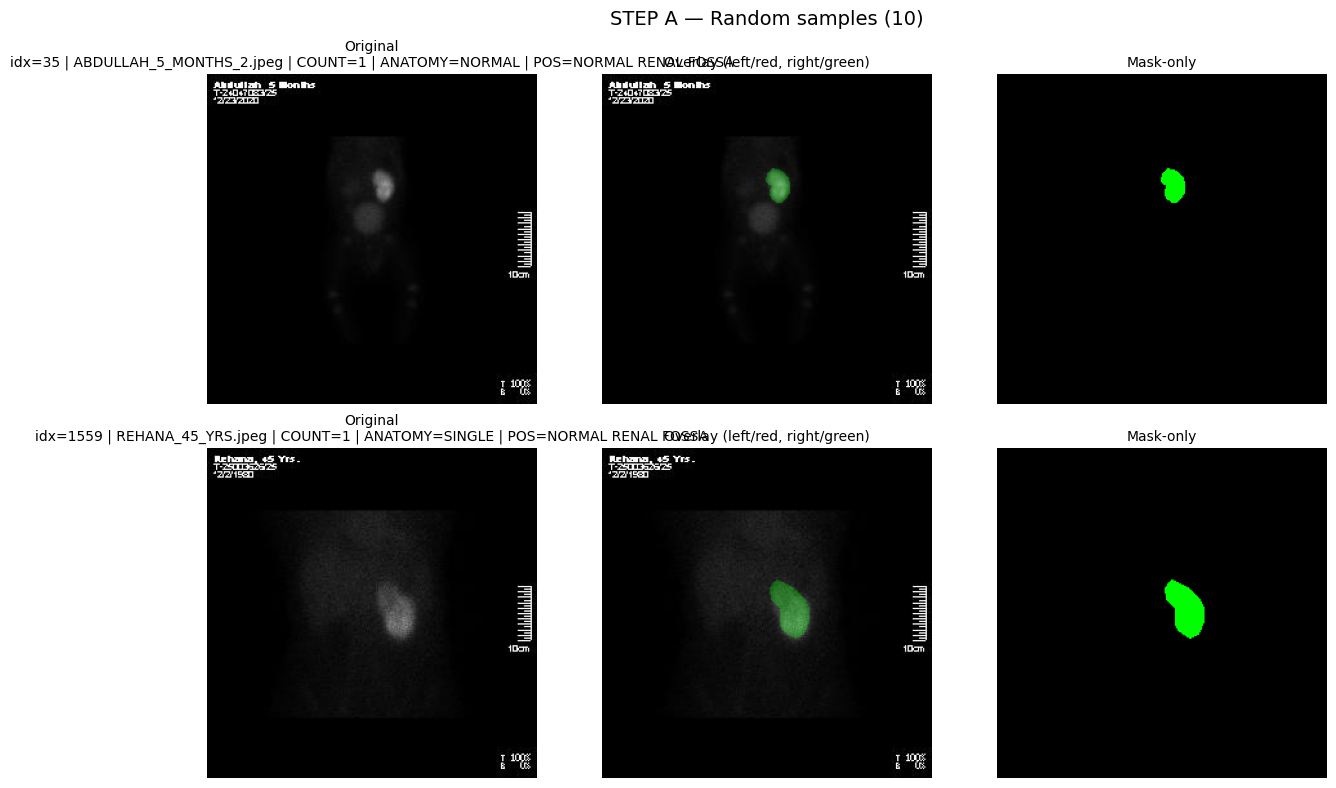

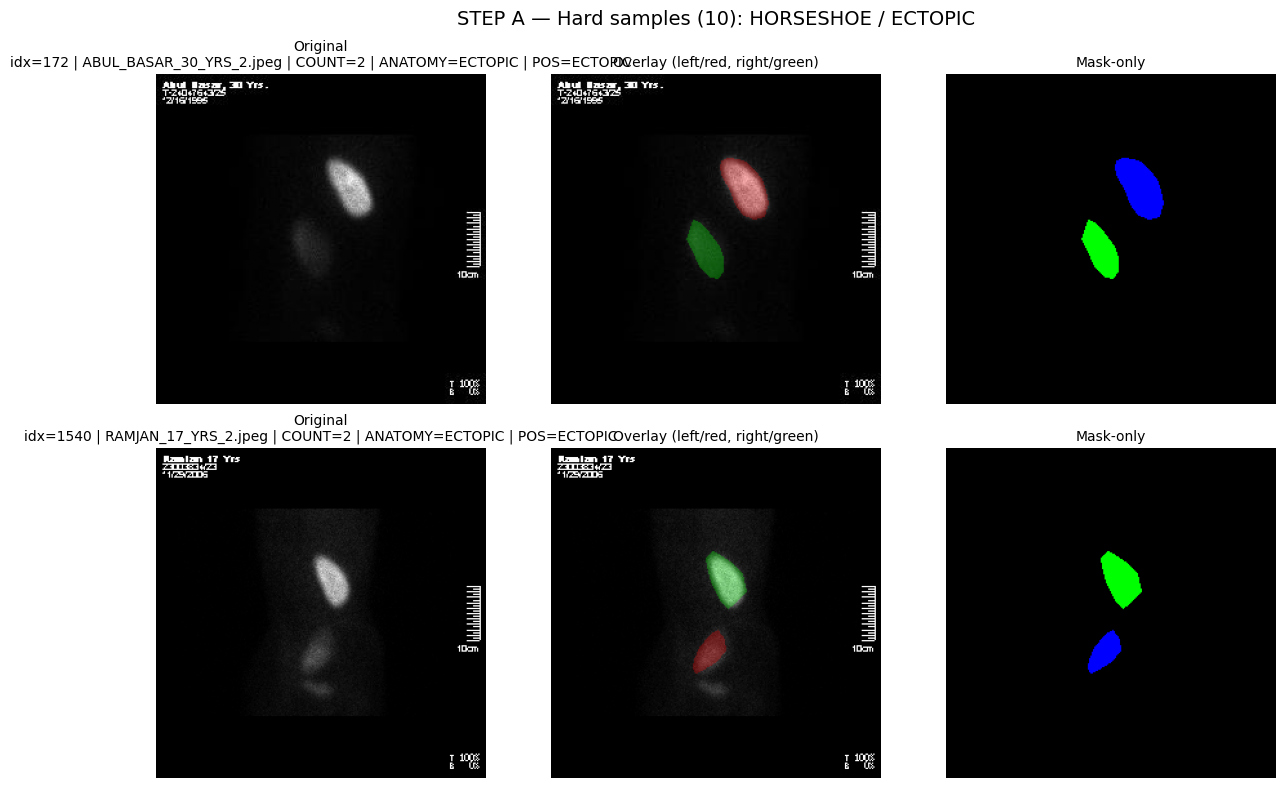

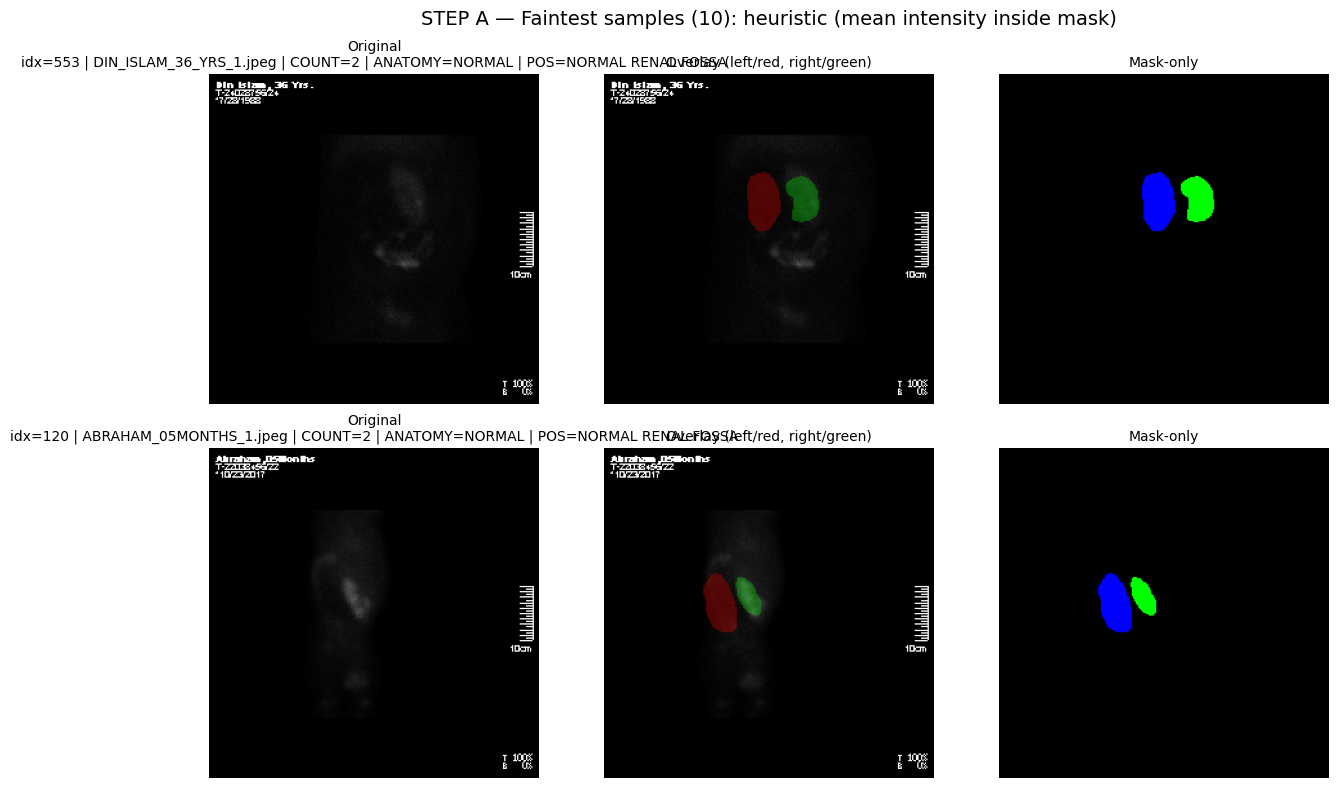

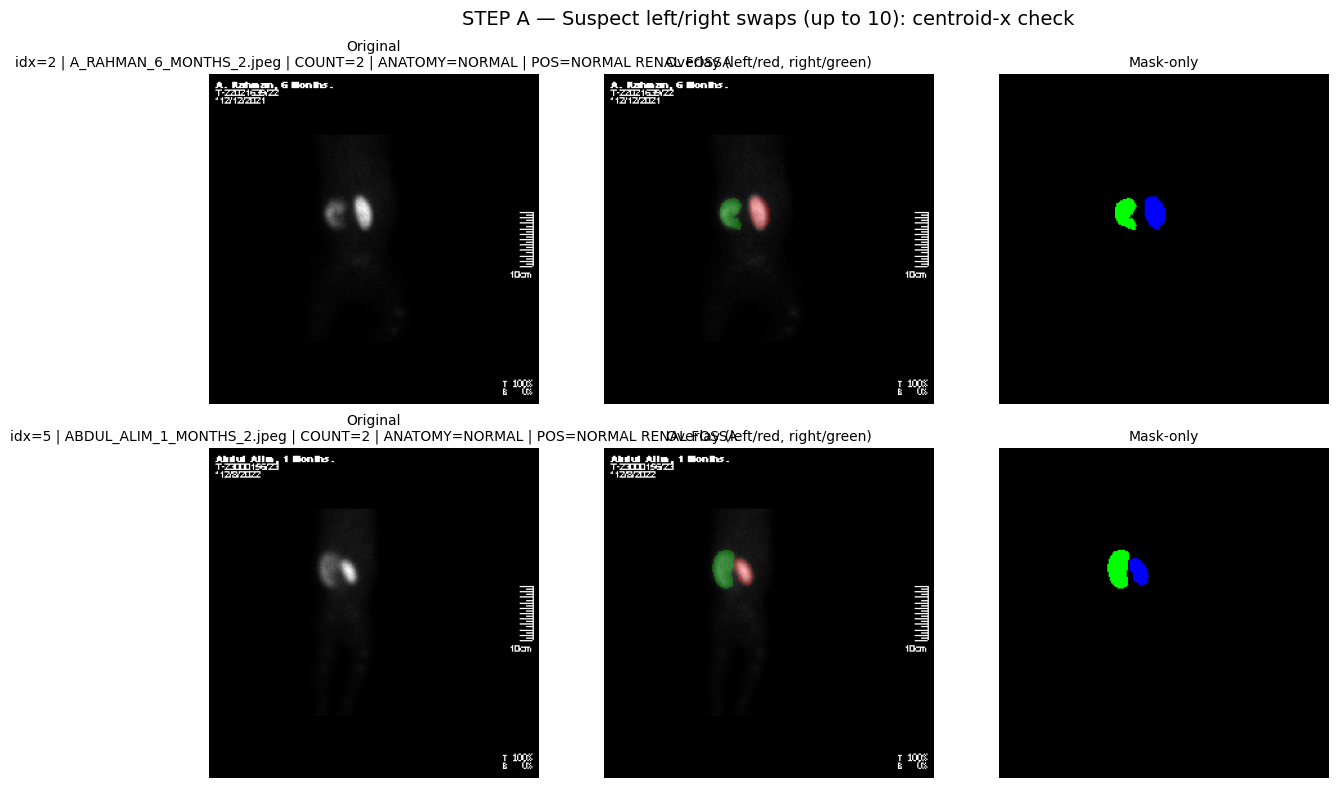

In [10]:
# CELL 10 — ADD NEW CELL (Run Step A: show 10 random + 10 hard + (optional) 10 faint + suspect swaps)

# 10 random samples
rand_idx = select_random_indices(n=2)
show_qc(rand_idx, "STEP A — Random samples (10)")

# 10 hard samples (horseshoe/ectopic/ectopic-position)
hard_idx = select_hard_indices(n=2)
show_qc(hard_idx, "STEP A — Hard samples (10): HORSESHOE / ECTOPIC")

# Optional: 10 faintest (by mean intensity inside mask union)
faint_idx = select_faint_indices(n=2)
show_qc(faint_idx, "STEP A — Faintest samples (10): heuristic (mean intensity inside mask)")

# Optional: suspect swaps by centroid-x rule
sus = swap_df.loc[swap_df["suspect_swap"], "idx"].tolist()
sus = sus[:2]
show_qc(sus, "STEP A — Suspect left/right swaps (up to 10): centroid-x check")


In [11]:
# CELL 11 — ADD NEW CELL (Find COUNT=2 cases where left/right mask is missing)

def _mask_area(mask_u8):
    return int((mask_u8 > 0).sum())

problems = []

for i in ok_idx:
    base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
    kc = int(df_use.loc[i, cfg.COL_COUNT])

    mask3, ml, mr = build_lr_mask_3class(base)
    aL = _mask_area(ml)
    aR = _mask_area(mr)

    if kc == 2 and (aL == 0 or aR == 0):
        problems.append({
            "idx": i,
            "basename": base,
            "VIEW": df_use.loc[i, "VIEW"],
            "Kidney COUNT": kc,
            "ANATOMY": df_use.loc[i, cfg.COL_ANATOMY],
            "POSITION": df_use.loc[i, cfg.COL_POSITION],
            "area_left": aL,
            "area_right": aR,
            "PATIENT NAME": df_use.loc[i, cfg.COL_PATIENT],
        })

problems_df = pd.DataFrame(problems)
print("COUNT=2 but missing a side mask:", len(problems_df))
if len(problems_df) > 0:
    print(problems_df.head(50)[["idx","basename","VIEW","area_left","area_right","ANATOMY","POSITION","PATIENT NAME"]])


COUNT=2 but missing a side mask: 0


In [12]:
# CELL 12 — ADD NEW CELL (Visualize the problematic COUNT=2 missing-side cases)

if "problems_df" not in globals() or len(problems_df) == 0:
    print("No COUNT=2 missing-side cases found (good).")
else:
    # Show up to 10 of them
    bad_idx = problems_df["idx"].tolist()[:10]
    show_qc(bad_idx, "STEP A — COUNT=2 but missing left/right mask (inspect these!)")


No COUNT=2 missing-side cases found (good).


In [13]:
# CELL 13 — ADD NEW CELL (QC: COUNT=1 but both masks present)

def _mask_area(mask_u8):
    return int((mask_u8 > 0).sum())

count1_both = []

for i in ok_idx:
    base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
    kc = int(df_use.loc[i, cfg.COL_COUNT])

    mask3, ml, mr = build_lr_mask_3class(base)
    aL = _mask_area(ml)
    aR = _mask_area(mr)

    if kc == 1 and (aL > 0 and aR > 0):
        count1_both.append({
            "idx": i,
            "basename": base,
            "VIEW": df_use.loc[i, "VIEW"],
            "Kidney COUNT": kc,
            "ANATOMY": df_use.loc[i, cfg.COL_ANATOMY],
            "POSITION": df_use.loc[i, cfg.COL_POSITION],
            "area_left": aL,
            "area_right": aR,
            "PATIENT NAME": df_use.loc[i, cfg.COL_PATIENT],
        })

count1_both_df = pd.DataFrame(count1_both)
print("COUNT=1 but BOTH left+right masks present:", len(count1_both_df))
if len(count1_both_df) > 0:
    print(count1_both_df.head(20)[["idx","basename","VIEW","area_left","area_right","ANATOMY","POSITION","PATIENT NAME"]])


COUNT=1 but BOTH left+right masks present: 0


In [14]:
# CELL 14 — ADD NEW CELL (QC: left/right overlap + tiny masks)

overlap_issues = []
tiny_issues = []

TINY_AREA_PX = 80  # conservative: anything smaller is almost surely junk; adjust if you want

for i in ok_idx:
    base = match_df.loc[match_df["idx"] == i, "basename"].values[0]
    kc = int(df_use.loc[i, cfg.COL_COUNT])

    mask3, ml, mr = build_lr_mask_3class(base)
    aL = _mask_area(ml)
    aR = _mask_area(mr)

    # overlap pixels
    overlap_px = int(((ml > 0) & (mr > 0)).sum())
    if overlap_px > 0:
        overlap_issues.append({
            "idx": i,
            "basename": base,
            "VIEW": df_use.loc[i, "VIEW"],
            "Kidney COUNT": kc,
            "overlap_px": overlap_px,
            "area_left": aL,
            "area_right": aR,
            "ANATOMY": df_use.loc[i, cfg.COL_ANATOMY],
            "POSITION": df_use.loc[i, cfg.COL_POSITION],
            "PATIENT NAME": df_use.loc[i, cfg.COL_PATIENT],
        })

    # tiny masks
    if (aL > 0 and aL < TINY_AREA_PX) or (aR > 0 and aR < TINY_AREA_PX):
        tiny_issues.append({
            "idx": i,
            "basename": base,
            "VIEW": df_use.loc[i, "VIEW"],
            "Kidney COUNT": kc,
            "area_left": aL,
            "area_right": aR,
            "ANATOMY": df_use.loc[i, cfg.COL_ANATOMY],
            "POSITION": df_use.loc[i, cfg.COL_POSITION],
            "PATIENT NAME": df_use.loc[i, cfg.COL_PATIENT],
        })

overlap_df = pd.DataFrame(overlap_issues)
tiny_df = pd.DataFrame(tiny_issues)

print("Overlap issues (left & right share pixels):", len(overlap_df))
if len(overlap_df) > 0:
    print(overlap_df.sort_values("overlap_px", ascending=False).head(15)[
        ["idx","basename","VIEW","overlap_px","area_left","area_right","ANATOMY","POSITION","PATIENT NAME"]
    ])

print("\nTiny mask issues (< {} px):".format(TINY_AREA_PX), len(tiny_df))
if len(tiny_df) > 0:
    print(tiny_df.head(15)[["idx","basename","VIEW","area_left","area_right","ANATOMY","POSITION","PATIENT NAME"]])


Overlap issues (left & right share pixels): 123
      idx                       basename VIEW  overlap_px  area_left  \
93   1668             SABID_8_YRS_3.jpeg  LPO         628        644   
63   1016        MAHAMUD_6_MONTHS_1.jpeg  LPO         533       1312   
76   1557            RAYHAN_23YRS_1.jpeg  LPO         405        756   
83   1579  RIDWANUR_RAHMAN_16_YRS_2.jpeg  RPO         397        534   
82   1578  RIDWANUR_RAHMAN_16_YRS_1.jpeg  LPO         293       1061   
91   1666             SABID_8_YRS_1.jpeg  LPO         288        514   
75   1556              RAYHAN_23YRS.jpeg    P         285        548   
92   1667             SABID_8_YRS_2.jpeg  RPO         284        520   
6     197     AFRA_SULTANA_02MONTHS.jpeg    P         263        485   
77   1558            RAYHAN_23YRS_2.jpeg  RPO         222        573   
81   1577    RIDWANUR_RAHMAN_16_YRS.jpeg    P         215       1248   
80   1570              RIAD_2_YRS_2.jpeg  RPO         200        381   
86   1613       

In [15]:
# CELL 15 — ADD NEW CELL (Visualize any QC issue list you want)

def show_issue_list(df_issues, title, n=10):
    if df_issues is None or len(df_issues) == 0:
        print(f"[{title}] No samples.")
        return
    idxs = df_issues["idx"].tolist()[:n]
    show_qc(idxs, title + f" (showing {min(n, len(idxs))})")

# Examples: uncomment what you want to view
# show_issue_list(problems_df, "COUNT=2 but missing a side mask", n=10)
# show_issue_list(count1_both_df, "COUNT=1 but both sides masked", n=10)
# show_issue_list(overlap_df, "Left/Right overlap", n=10)
# show_issue_list(tiny_df, "Tiny masks", n=10)

print("Ready — uncomment one or more show_issue_list(...) lines and run.")


Ready — uncomment one or more show_issue_list(...) lines and run.


In [16]:
# CELL 16 — ADD NEW CELL (Step B: deterministic seed + device)

import random
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [17]:
# CELL 17 — FULL REPLACEMENT (Step B: Patient-group split, no leakage)

from sklearn.model_selection import GroupShuffleSplit

# Keep only rows that have image+json available (ok_idx from Step A)
df_seg = df_use.loc[ok_idx].copy()
df_seg.reset_index(drop=False, inplace=True)  # keep original index in a column named 'index' (no CSV edits)

groups_seg = df_seg[cfg.COL_PATIENT].astype(str).values

# 1) Split out TEST (10%) by patient groups
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
trainval_idx, test_idx = next(gss.split(df_seg, groups=groups_seg))

df_trainval = df_seg.iloc[trainval_idx].copy().reset_index(drop=True)
df_test = df_seg.iloc[test_idx].copy().reset_index(drop=True)

# 2) Split TRAIN/VAL from TRAINVAL.
# We want ~10% of full set as VAL. Since trainval is 90%,
# val fraction inside trainval should be 0.10 / 0.90 = 0.1111...
val_frac_inside_trainval = 0.10 / 0.90

gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac_inside_trainval, random_state=42)
train_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval[cfg.COL_PATIENT].astype(str).values))

df_train = df_trainval.iloc[train_idx].copy().reset_index(drop=True)
df_val = df_trainval.iloc[val_idx].copy().reset_index(drop=True)

print("Seg rows total:", len(df_seg))
print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))

# Sanity: patient leakage check
p_train = set(df_train[cfg.COL_PATIENT].astype(str).tolist())
p_val = set(df_val[cfg.COL_PATIENT].astype(str).tolist())
p_test = set(df_test[cfg.COL_PATIENT].astype(str).tolist())

assert len(p_train & p_val) == 0, "Patient leakage between train and val!"
assert len(p_train & p_test) == 0, "Patient leakage between train and test!"
assert len(p_val & p_test) == 0, "Patient leakage between val and test!"
print("OK — Patient-group split has no leakage")


Seg rows total: 2285
Train: 1772 Val: 259 Test: 254
OK — Patient-group split has no leakage


In [18]:
# CELL 18 — ADD NEW CELL (Step B: Mask generator helper + optional VIEW flip handling)

def apply_view_standardization(img_u8, mask3_u8, view_value):
    """
    Earlier phases: RPO (and RLO if present) are horizontally flipped.
    We must apply the SAME flip to the mask for segmentation training consistency.
    """
    v = str(view_value).strip().upper()

    if v in ["RPO", "RLO"]:
        img_u8 = cv2.flip(img_u8, 1)       # horizontal flip
        mask3_u8 = cv2.flip(mask3_u8, 1)   # horizontal flip
    return img_u8, mask3_u8

def get_img_and_mask3_from_row(row):
    """
    STRICT: use LINK as-is (relative allowed only under cfg.BASE_DIR).
    Mask is built from JSON using basename(LINK).
    """
    link = row[cfg.COL_LINK]
    base = _basename_from_link(link)

    img_path = resolve_image_path_from_link_strict(link)
    img = load_gray_256(img_path)

    mask3, _, _ = build_lr_mask_3class(base)

    # Apply view standardization consistently (if you used it before, keep it now)
    if "VIEW" in row.index:
        img, mask3 = apply_view_standardization(img, mask3, row["VIEW"])

    return img, mask3


In [19]:
# CELL 19 — ADD NEW CELL (Step B: PyTorch Dataset + safe augmentations for medical data)

from torch.utils.data import Dataset, DataLoader

class DMSASegDataset(Dataset):
    def __init__(self, df, training=False):
        self.df = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def _augment(self, img, mask3):
        """
        Conservative augmentations only:
        - small brightness/contrast jitter
        - small gaussian noise
        - optional small translation
        No aggressive rotations/scaling that could alter anatomy interpretation.
        """
        if not self.training:
            return img, mask3

        # brightness/contrast
        if np.random.rand() < 0.5:
            alpha = 1.0 + np.random.uniform(-0.08, 0.08)  # contrast
            beta = np.random.uniform(-8, 8)               # brightness
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        # mild noise
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 3.0, img.shape).astype(np.float32)
            img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        # small translation (same for mask)
        if np.random.rand() < 0.3:
            tx = int(np.random.uniform(-4, 4))
            ty = int(np.random.uniform(-4, 4))
            M = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(img, M, (256, 256), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
            mask3 = cv2.warpAffine(mask3, M, (256, 256), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        return img, mask3

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img, mask3 = get_img_and_mask3_from_row(row)

        img, mask3 = self._augment(img, mask3)

        # image -> float32 [0,1], shape [1,H,W]
        x = img.astype(np.float32) / 255.0
        x = torch.from_numpy(x).unsqueeze(0)

        # mask -> long [H,W] with values 0,1,2
        y = torch.from_numpy(mask3.astype(np.int64))

        return x, y

train_ds = DMSASegDataset(df_train, training=True)
val_ds   = DMSASegDataset(df_val, training=False)
test_ds  = DMSASegDataset(df_test, training=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print("OK — Dataloaders ready")
print("Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))


OK — Dataloaders ready
Train batches: 111 Val batches: 17 Test batches: 16


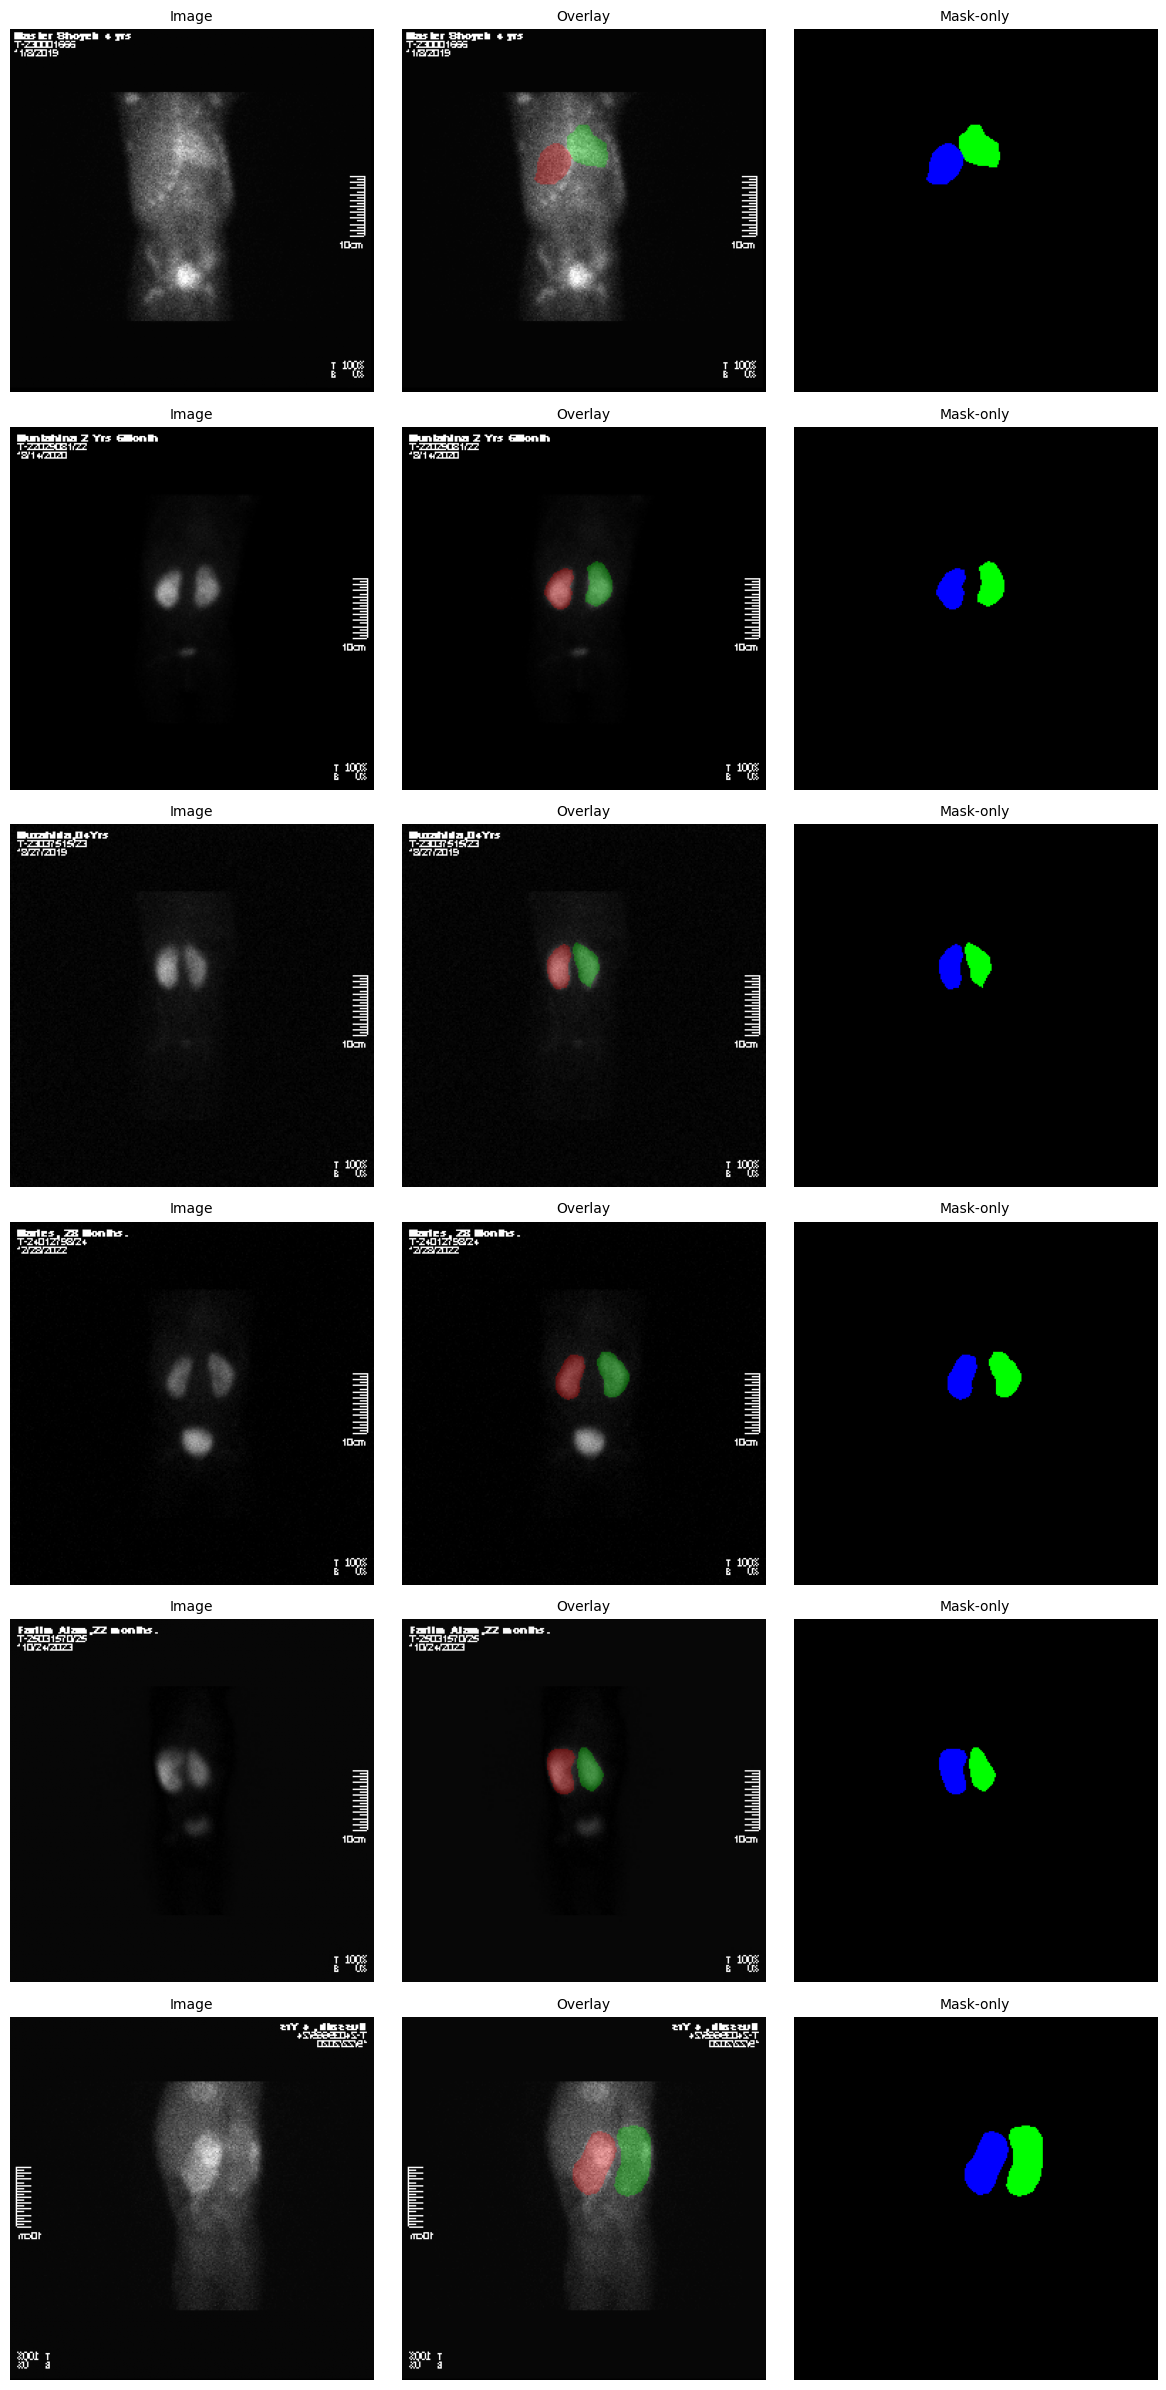

In [20]:
# CELL 20 — ADD NEW CELL (Step B: quick batch sanity + visualize a few masks)

def show_seg_batch(loader, n=6):
    xb, yb = next(iter(loader))
    xb = xb[:n].cpu().numpy()
    yb = yb[:n].cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = (xb[i,0] * 255.0).astype(np.uint8)
        mask3 = yb[i].astype(np.uint8)

        ov = make_overlay(img, mask3)
        mo = mask_only_rgb(mask3)

        axes[i,0].imshow(img, cmap="gray")
        axes[i,0].set_title("Image", fontsize=10)
        axes[i,0].axis("off")

        axes[i,1].imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
        axes[i,1].set_title("Overlay", fontsize=10)
        axes[i,1].axis("off")

        axes[i,2].imshow(mo)
        axes[i,2].set_title("Mask-only", fontsize=10)
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

show_seg_batch(train_loader, n=6)


In [21]:
# CELL 21 — ADD NEW CELL (Step B: ResNet18-encoder U-Net (1-channel input, 3-class output))

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import torchvision
    from torchvision import models
    print("torchvision:", torchvision.__version__)
except Exception as e:
    raise ImportError("torchvision is required for ResNet18 encoder. Install/enable torchvision.") from e


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv1 = ConvBNReLU(out_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Safety: align shapes (should already match for 256x256 path)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class ResNet18Encoder(nn.Module):
    def __init__(self, pretrained=True, in_ch=1):
        super().__init__()

        # torchvision API compatibility
        try:
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            backbone = models.resnet18(weights=weights)
        except Exception:
            backbone = models.resnet18(pretrained=pretrained)

        # Convert first conv to 1-channel if needed
        if in_ch == 1:
            old = backbone.conv1
            new = nn.Conv2d(1, old.out_channels, kernel_size=old.kernel_size, stride=old.stride,
                            padding=old.padding, bias=False)
            with torch.no_grad():
                if old.weight.shape[1] == 3:
                    new.weight.copy_(old.weight.mean(dim=1, keepdim=True))
                else:
                    new.weight.copy_(old.weight)
            backbone.conv1 = new

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):
        # x: [B,1,256,256]
        x = self.conv1(x)   # [B,64,128,128]
        x = self.bn1(x)
        x0 = self.relu(x)   # skip0: [B,64,128,128]

        x = self.maxpool(x0)      # [B,64,64,64]
        x1 = self.layer1(x)       # skip1: [B,64,64,64]
        x2 = self.layer2(x1)      # skip2: [B,128,32,32]
        x3 = self.layer3(x2)      # skip3: [B,256,16,16]
        x4 = self.layer4(x3)      # bottleneck: [B,512,8,8]
        return x0, x1, x2, x3, x4


class UNetResNet18(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        self.enc = ResNet18Encoder(pretrained=pretrained, in_ch=1)

        self.bottleneck = nn.Sequential(
            ConvBNReLU(512, 512),
            ConvBNReLU(512, 512),
        )

        self.up3 = UpBlock(in_ch=512, skip_ch=256, out_ch=256)  # 8->16
        self.up2 = UpBlock(in_ch=256, skip_ch=128, out_ch=128)  # 16->32
        self.up1 = UpBlock(in_ch=128, skip_ch=64,  out_ch=64)   # 32->64
        self.up0 = UpBlock(in_ch=64,  skip_ch=64,  out_ch=64)   # 64->128

        self.final_up = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 128->256
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x0, x1, x2, x3, x4 = self.enc(x)
        x = self.bottleneck(x4)

        x = self.up3(x, x3)
        x = self.up2(x, x2)
        x = self.up1(x, x1)
        x = self.up0(x, x0)

        x = self.final_up(x)
        logits = self.head(x)  # [B,3,256,256]
        return logits


model = UNetResNet18(num_classes=3, pretrained=True).to(DEVICE)
print("OK — Model created:", model.__class__.__name__)


torchvision: 0.20.1+cu121
OK — Model created: UNetResNet18


In [22]:
# CELL 22 — ADD NEW CELL (Step B: Loss = Weighted CE + Soft Dice (multi-class))

def compute_class_weights_from_loader(loader, num_classes=3, max_batches=30):
    """
    Conservative estimate of pixel class imbalance from TRAIN loader.
    Returns torch.tensor [C] on CPU.
    """
    counts = np.zeros((num_classes,), dtype=np.float64)
    seen = 0

    for xb, yb in loader:
        y = yb.numpy()
        for c in range(num_classes):
            counts[c] += (y == c).sum()
        seen += 1
        if seen >= max_batches:
            break

    counts = np.maximum(counts, 1.0)
    freq = counts / counts.sum()
    inv = 1.0 / freq
    w = inv / inv.sum() * num_classes
    return torch.tensor(w, dtype=torch.float32)

# Compute weights from training masks (helps background dominance)
ce_weights = compute_class_weights_from_loader(train_loader, num_classes=3, max_batches=30)
print("CE class weights [bg,left,right]:", ce_weights.tolist())

ce_loss_fn = nn.CrossEntropyLoss(weight=ce_weights.to(DEVICE))

def soft_dice_loss(logits, target, num_classes=3, eps=1e-6):
    """
    logits: [B,C,H,W]
    target: [B,H,W] long
    Dice computed per class; returns (1 - mean_dice_over_non_bg)
    """
    probs = torch.softmax(logits, dim=1)  # [B,C,H,W]
    target_1h = F.one_hot(target, num_classes=num_classes).permute(0,3,1,2).float()  # [B,C,H,W]

    dims = (0,2,3)
    inter = torch.sum(probs * target_1h, dims)
    denom = torch.sum(probs + target_1h, dims)

    dice = (2.0 * inter + eps) / (denom + eps)  # [C]
    # exclude background for training signal
    dice_fg = dice[1:].mean()
    return 1.0 - dice_fg

def total_loss(logits, target):
    return ce_loss_fn(logits, target) + soft_dice_loss(logits, target, num_classes=3)


CE class weights [bg,left,right]: [0.011523119173943996, 1.4996641874313354, 1.4888126850128174]


In [23]:
# CELL 23 — ADD NEW CELL (Step B: Metrics + evaluation helpers)

@torch.no_grad()
def dice_per_class_from_logits(logits, target, num_classes=3, eps=1e-6):
    pred = torch.argmax(logits, dim=1)  # [B,H,W]
    dices = []
    for c in range(num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        d = (2.0 * inter + eps) / (denom + eps)
        dices.append(d.item())
    return dices  # [bg, left, right]

@torch.no_grad()
def run_eval(model, loader, num_classes=3):
    model.eval()
    loss_sum = 0.0
    n = 0

    dice_sum = np.zeros((num_classes,), dtype=np.float64)

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        logits = model(xb)
        loss = total_loss(logits, yb)

        loss_sum += float(loss.item()) * xb.size(0)
        n += xb.size(0)

        d = dice_per_class_from_logits(logits, yb, num_classes=num_classes)
        dice_sum += np.array(d) * xb.size(0)

    out = {
        "loss": loss_sum / max(n, 1),
        "dice_bg": dice_sum[0] / max(n, 1),
        "dice_left": dice_sum[1] / max(n, 1),
        "dice_right": dice_sum[2] / max(n, 1),
        "dice_fg_mean": (dice_sum[1] + dice_sum[2]) / max(2*n, 1),
    }
    return out


In [24]:
# CELL 24 — ADD NEW CELL (Step B: Training loop + checkpointing)

from copy import deepcopy
from tqdm import tqdm

SEG_EPOCHS = 30
SEG_LR = 1e-3
SEG_WD = 1e-4
SEG_PATIENCE = 8
SEG_CKPT_PATH = str(cfg.BASE_DIR / "phase4A_unet_resnet18_best.pth")

optimizer = torch.optim.AdamW(model.parameters(), lr=SEG_LR, weight_decay=SEG_WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, verbose=True)

use_amp = (DEVICE.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

best = {"epoch": -1, "dice_fg_mean": -1.0, "state": None}

pat = 0
history = []

for epoch in range(1, SEG_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    n_train = 0

    pbar = tqdm(train_loader, total=len(train_loader), desc=f"[SEG][{epoch:02d}]")
    for xb, yb in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(xb)
            loss = total_loss(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += float(loss.item()) * xb.size(0)
        n_train += xb.size(0)

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    train_loss = train_loss_sum / max(n_train, 1)
    val_metrics = run_eval(model, val_loader, num_classes=3)

    scheduler.step(val_metrics["dice_fg_mean"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history.append(row)

    print(f"[SEG][{epoch:02d}] train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_dice_fg={val_metrics['dice_fg_mean']:.4f} "
          f"(L={val_metrics['dice_left']:.4f}, R={val_metrics['dice_right']:.4f})")

    # checkpoint best by fg dice mean
    if val_metrics["dice_fg_mean"] > best["dice_fg_mean"]:
        best["epoch"] = epoch
        best["dice_fg_mean"] = float(val_metrics["dice_fg_mean"])
        best["state"] = deepcopy(model.state_dict())
        torch.save({"epoch": epoch, "state_dict": best["state"], "val_metrics": val_metrics}, SEG_CKPT_PATH)
        print("  -> saved BEST:", SEG_CKPT_PATH)
        pat = 0
    else:
        pat += 1
        if pat >= SEG_PATIENCE:
            print("Early stop triggered.")
            break

print("\nBEST epoch:", best["epoch"], "BEST val dice_fg_mean:", best["dice_fg_mean"])


[SEG][01]: 100%|██████████| 111/111 [01:20<00:00,  1.38it/s, loss=0.3631]


[SEG][01] train_loss=0.8954 | val_loss=0.7032 | val_dice_fg=0.7535 (L=0.7771, R=0.7300)
  -> saved BEST: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4A_unet_resnet18_best.pth


[SEG][02]: 100%|██████████| 111/111 [01:21<00:00,  1.37it/s, loss=0.3122]


[SEG][02] train_loss=0.5365 | val_loss=0.6823 | val_dice_fg=0.6923 (L=0.6907, R=0.6939)


[SEG][03]: 100%|██████████| 111/111 [01:20<00:00,  1.37it/s, loss=0.3612]


...

[SEG][28] train_loss=0.1918 | val_loss=0.6177 | val_dice_fg=0.8108 (L=0.8259, R=0.7956)


[SEG][29]: 100%|██████████| 111/111 [01:19<00:00,  1.39it/s, loss=0.1730]


[SEG][29] train_loss=0.1906 | val_loss=0.6339 | val_dice_fg=0.8100 (L=0.8172, R=0.8028)


[SEG][30]: 100%|██████████| 111/111 [01:19<00:00,  1.39it/s, loss=0.1939]


[SEG][30] train_loss=0.1850 | val_loss=0.6391 | val_dice_fg=0.8119 (L=0.8160, R=0.8079)

BEST epoch: 25 BEST val dice_fg_mean: 0.8144845579351697


In [25]:
# CELL 25 — ADD NEW CELL (Step B: Load best checkpoint + test metrics)

ckpt = torch.load(SEG_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

test_metrics = run_eval(model, test_loader, num_classes=3)

print("Loaded BEST from:", SEG_CKPT_PATH)
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")


Loaded BEST from: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4A_unet_resnet18_best.pth
Test metrics:
  loss: 0.5567
  dice_bg: 0.9976
  dice_left: 0.8239
  dice_right: 0.8218
  dice_fg_mean: 0.8228


In [29]:
# CELL 27 — FULL REPLACEMENT (Phase-4A Step C: Ruler ROI proof — crop + WHITE-tick span detector)

def crop_ruler_roi(img_u8):
    """
    Crop the LOCKED ruler ROI from the ORIGINAL (unflipped) 256x256 image.
    This is for calibration proof only.
    """
    assert img_u8.shape == (256, 256), f"Expected 256x256, got {img_u8.shape}"
    x0, x1 = cfg.RULER_X0, cfg.RULER_X1
    y0, y1 = cfg.RULER_Y0, cfg.RULER_Y1
    roi = img_u8[y0:y1, x0:x1].copy()
    return roi

def detect_tick_span_px(roi_u8, min_peak_frac=0.45):
    """
    Detect first and last tick rows inside the locked ROI for WHITE ruler/ticks on BLACK background.

    Returns: (span_px, y_first, y_last, bin_img, row_sum, thr)

    Method:
    - Otsu BINARY (white -> 255)
    - Row projection sum
    - Dynamic threshold: rows that are strong peaks vs baseline
    - Segment contiguous rows; tick location = segment center
    """
    assert roi_u8.ndim == 2, "ROI must be grayscale"
    h, w = roi_u8.shape

    # Light smoothing helps Otsu be stable
    blur = cv2.GaussianBlur(roi_u8, (3, 3), 0)

    # WHITE on BLACK => standard binary Otsu (not inverse)
    _, bin_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Row-wise count of white pixels
    row_sum = (bin_img > 0).sum(axis=1).astype(np.int32)

    # Baseline is usually near the thin vertical ruler line (small count),
    # tick rows become peaks (larger count).
    baseline = float(np.median(row_sum))
    peak = float(np.max(row_sum))

    # Dynamic threshold: pick rows that are much higher than baseline
    # and at least a fraction of peak.
    thr1 = baseline + 2.0
    thr2 = peak * float(min_peak_frac)
    thr = int(max(1, round(max(thr1, thr2))))

    mask_rows = row_sum >= thr

    # Find contiguous True segments and take their centers
    tick_centers = []
    in_seg = False
    seg_start = 0

    for y in range(h):
        if mask_rows[y] and not in_seg:
            in_seg = True
            seg_start = y
        if (not mask_rows[y] and in_seg) or (in_seg and y == h - 1 and mask_rows[y]):
            seg_end = y if not mask_rows[y] else y
            cy = int(round((seg_start + seg_end) / 2.0))
            tick_centers.append(cy)
            in_seg = False

    # Must have at least first+last tick
    if len(tick_centers) < 2:
        return None, None, None, bin_img, row_sum, thr

    y_first = int(tick_centers[0])
    y_last = int(tick_centers[-1])
    span_px = int(y_last - y_first)

    return span_px, y_first, y_last, bin_img, row_sum, thr

print("OK — Updated WHITE-tick ruler span detector ready")


OK — Updated WHITE-tick ruler span detector ready


Example idx: 0 | basename: A_RAHMAN_6_MONTHS.jpeg
Ruler ROI shape: (46, 13)
RowSum baseline/peak: 7.0 12.0 | thr: 9
Detected span_px: 43 | y_first: 1 | y_last: 44
ppcm from this example: 4.3


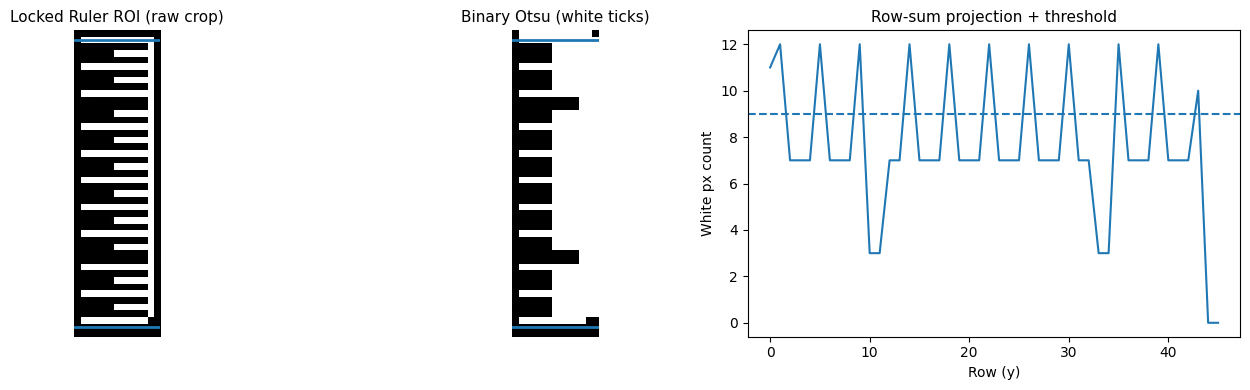

In [30]:
# CELL 28 — FULL REPLACEMENT (Show ruler ROI crop + detected first/last tick, with row-sum debug)

assert len(ok_idx) > 0, "ok_idx is empty — Step A matching failed."

i0 = ok_idx[0]
row0 = df_use.loc[i0]
link0 = row0[cfg.COL_LINK]
base0 = _basename_from_link(link0)

img_path0 = resolve_image_path_from_link_strict(link0)
img0 = load_gray_256(img_path0)

roi0 = crop_ruler_roi(img0)
span_px0, y_first0, y_last0, bin0, row_sum0, thr0 = detect_tick_span_px(roi0)

print("Example idx:", i0, "| basename:", base0)
print("Ruler ROI shape:", roi0.shape)
print("RowSum baseline/peak:", float(np.median(row_sum0)), float(np.max(row_sum0)), "| thr:", thr0)
print("Detected span_px:", span_px0, "| y_first:", y_first0, "| y_last:", y_last0)
if span_px0 is not None:
    print("ppcm from this example:", span_px0 / 10.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(roi0, cmap="gray")
axes[0].set_title("Locked Ruler ROI (raw crop)", fontsize=11)
axes[0].axis("off")
if y_first0 is not None and y_last0 is not None:
    axes[0].axhline(y_first0, linewidth=2)
    axes[0].axhline(y_last0, linewidth=2)

axes[1].imshow(bin0, cmap="gray")
axes[1].set_title("Binary Otsu (white ticks)", fontsize=11)
axes[1].axis("off")
if y_first0 is not None and y_last0 is not None:
    axes[1].axhline(y_first0, linewidth=2)
    axes[1].axhline(y_last0, linewidth=2)

axes[2].plot(row_sum0)
axes[2].axhline(thr0, linestyle="--")
axes[2].set_title("Row-sum projection + threshold", fontsize=11)
axes[2].set_xlabel("Row (y)")
axes[2].set_ylabel("White px count")

plt.tight_layout()
plt.show()


Calibration verification sample size: 30
Successful detections: 30
Failed detections: 0

span_px stats (should be stable near your reference, e.g., 42):
  mean: 43.0
  std : 0.0
  min : 43
  max : 43
  implied ppcm mean: 4.3


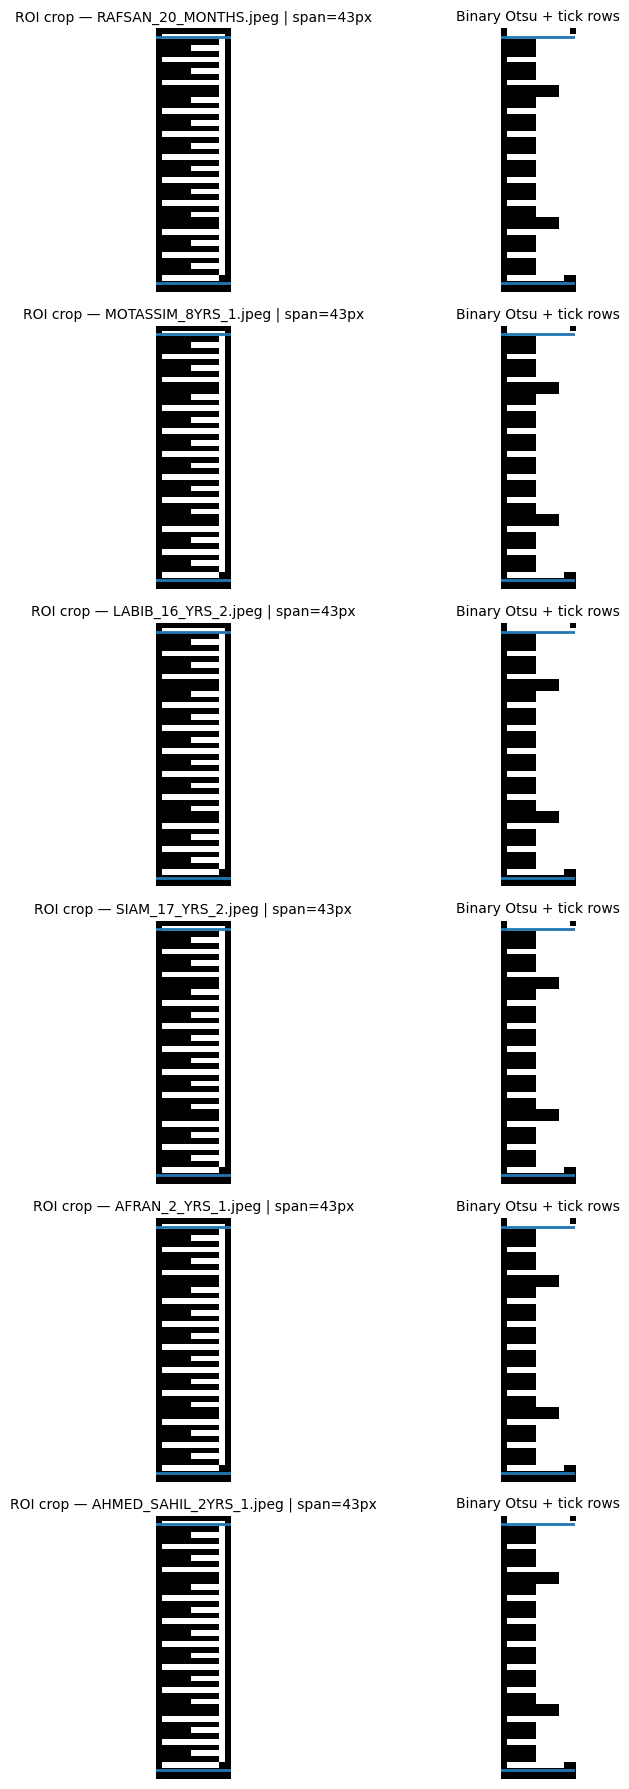

In [31]:
# CELL 29 — FULL REPLACEMENT (Calibration proof across random images + show multiple ruler crops)

rng = np.random.default_rng(42)
N_CAL = 30
sample_idx = rng.choice(ok_idx, size=min(N_CAL, len(ok_idx)), replace=False).tolist()

spans = []
failed = []
examples = []

for i in sample_idx:
    row = df_use.loc[i]
    link = row[cfg.COL_LINK]
    base = _basename_from_link(link)

    try:
        img_path = resolve_image_path_from_link_strict(link)
        img = load_gray_256(img_path)
        roi = crop_ruler_roi(img)

        span_px, y_first, y_last, bin_img, row_sum, thr = detect_tick_span_px(roi)

        if span_px is None:
            failed.append((i, base))
            continue

        spans.append(span_px)

        if len(examples) < 6:
            examples.append((i, base, roi, bin_img, y_first, y_last, span_px))

    except Exception:
        failed.append((i, base))

spans = np.array(spans, dtype=np.int32)

print("Calibration verification sample size:", len(sample_idx))
print("Successful detections:", len(spans))
print("Failed detections:", len(failed))

if len(spans) == 0:
    raise RuntimeError("All ruler span detections failed — cannot produce calibration proof.")

print("\nspan_px stats (should be stable near your reference, e.g., 42):")
print("  mean:", float(spans.mean()))
print("  std :", float(spans.std()))
print("  min :", int(spans.min()))
print("  max :", int(spans.max()))
print("  implied ppcm mean:", float(spans.mean()) / 10.0)

# This proof step must show stability; if it doesn't, ROI coords or standardization is inconsistent.
assert float(spans.std()) <= 1.0, "Ruler span variation too high — ROI or image standardization mismatch."

fig, axes = plt.subplots(len(examples), 2, figsize=(10, 3*len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, (i, base, roi, bin_img, y_first, y_last, span_px) in enumerate(examples):
    axes[r, 0].imshow(roi, cmap="gray")
    axes[r, 0].set_title(f"ROI crop — {base} | span={span_px}px", fontsize=10)
    axes[r, 0].axis("off")
    axes[r, 0].axhline(y_first, linewidth=2)
    axes[r, 0].axhline(y_last, linewidth=2)

    axes[r, 1].imshow(bin_img, cmap="gray")
    axes[r, 1].set_title("Binary Otsu + tick rows", fontsize=10)
    axes[r, 1].axis("off")
    axes[r, 1].axhline(y_first, linewidth=2)
    axes[r, 1].axhline(y_last, linewidth=2)

plt.tight_layout()
plt.show()


In [36]:
# CELL 30 — ADD NEW CELL (Lock PPCM from calibration proof)

# Use calibration result if available (from CELL 29); otherwise fall back to cfg.PPCM_LOCKED
if "spans" in globals() and isinstance(spans, np.ndarray) and len(spans) > 0:
    PPCM_USED = float(spans.mean()) / 10.0
else:
    PPCM_USED = float(cfg.PPCM_LOCKED)

print("PPCM_USED:", PPCM_USED)

# If your proof shows ~4.3, this becomes the constant for Step C
# We do NOT re-detect: we just use PPCM_USED everywhere.


PPCM_USED: 4.3


In [37]:
# CELL 31 — ADD NEW CELL (Mask post-processing: keep largest component per class)

def keep_largest_component(bin_mask_u8):
    """
    bin_mask_u8: uint8 0/1 mask
    returns uint8 0/1 with only largest connected component kept
    """
    m = (bin_mask_u8 > 0).astype(np.uint8)
    if m.sum() == 0:
        return m

    num, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if num <= 1:
        return m

    # stats: [label, x, y, w, h, area] for each component (0 is background)
    areas = stats[1:, cv2.CC_STAT_AREA]
    best = 1 + int(np.argmax(areas))
    out = (labels == best).astype(np.uint8)
    return out

def postprocess_pred_mask3(pred_mask3_u8):
    """
    pred_mask3_u8: uint8 with values {0,1,2}
    returns cleaned_mask3_u8 with largest component kept for left and right separately.
    """
    out = np.zeros((256,256), dtype=np.uint8)

    left = (pred_mask3_u8 == 1).astype(np.uint8)
    right = (pred_mask3_u8 == 2).astype(np.uint8)

    left = keep_largest_component(left)
    right = keep_largest_component(right)

    out[left > 0] = 1
    out[right > 0] = 2

    return out


In [38]:
# CELL 32 — ADD NEW CELL (Kidney length in px via PCA major-axis extent, tilt-aware)

def pca_major_axis_length_px(bin_mask_u8, trim_percent=2.0):
    """
    bin_mask_u8: uint8 0/1
    Returns (length_px, endpoint1_xy, endpoint2_xy)
      - length_px: float
      - endpoints: (x,y) tuples in image coords
    Uses PCA on pixel coordinates; length is robust extent along first PC using percentiles.
    """
    ys, xs = np.where(bin_mask_u8 > 0)
    if len(xs) < 20:
        return None, None, None

    pts = np.stack([xs, ys], axis=1).astype(np.float32)  # [N,2] (x,y)

    # Center
    mu = pts.mean(axis=0, keepdims=True)
    X = pts - mu

    # PCA via SVD (2D)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    v1 = Vt[0]  # first principal direction (unit)

    # Project onto v1
    t = X @ v1  # [N]

    lo = np.percentile(t, trim_percent)
    hi = np.percentile(t, 100.0 - trim_percent)
    length = float(hi - lo)
    if length <= 0:
        return None, None, None

    # Endpoints back in xy:
    p1 = (mu[0] + lo * v1).ravel()
    p2 = (mu[0] + hi * v1).ravel()

    # clip endpoints
    p1[0] = float(np.clip(p1[0], 0, 255)); p1[1] = float(np.clip(p1[1], 0, 255))
    p2[0] = float(np.clip(p2[0], 0, 255)); p2[1] = float(np.clip(p2[1], 0, 255))

    return length, (p1[0], p1[1]), (p2[0], p2[1])


In [40]:
# CELL 33 — FULL REPLACEMENT (Run Step C: predict masks -> length_px -> cm, save results table in memory)

@torch.no_grad()
def predict_mask3(img_u8, view_value=None):
    """
    img_u8: [256,256] uint8
    returns pred_mask3 uint8 with values 0/1/2
    Applies same VIEW flip rule if provided.
    """
    # Ensure model is in eval mode for inference
    model.eval()

    mask_dummy = np.zeros((256,256), dtype=np.uint8)

    if view_value is not None:
        img_u8, _ = apply_view_standardization(img_u8, mask_dummy, view_value)

    x = (img_u8.astype(np.float32) / 255.0)
    x = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy().astype(np.uint8)
    return pred

def compute_overlap_flag(mask3_u8):
    """
    Overlap can happen in fused cases. With argmax masks, pixel-level overlap isn't present,
    but fused anatomy still shows as a single connected structure.
    We flag fusion if left+right components touch or are very close after dilation.
    """
    left = (mask3_u8 == 1).astype(np.uint8)
    right = (mask3_u8 == 2).astype(np.uint8)
    if left.sum() == 0 or right.sum() == 0:
        return False

    kernel = np.ones((3,3), np.uint8)
    left_d = cv2.dilate(left, kernel, iterations=1)
    touch = int((left_d & right).sum()) > 0
    return bool(touch)

results = []

# Measure on the same usable set used for segmentation (df_seg built in CELL 17)
# If df_seg not present, fall back to df_use rows indexed by ok_idx.
if "df_seg" in globals():
    iter_df = df_seg
    iter_rows = range(len(iter_df))
    mode_name = "df_seg"
else:
    iter_df = df_use
    iter_rows = ok_idx
    mode_name = "df_use(ok_idx)"

print("Measuring on:", mode_name)

for j in iter_rows:
    row = iter_df.iloc[j] if mode_name == "df_seg" else iter_df.loc[j]

    link = row[cfg.COL_LINK]
    base = _basename_from_link(link)
    view = row["VIEW"] if "VIEW" in iter_df.columns else None

    # Load image
    img_path = resolve_image_path_from_link_strict(link)
    img = load_gray_256(img_path)

    # Predict mask
    pred_mask3 = predict_mask3(img, view_value=view)
    pred_mask3 = postprocess_pred_mask3(pred_mask3)

    # Split into left/right binary masks
    mL = (pred_mask3 == 1).astype(np.uint8)
    mR = (pred_mask3 == 2).astype(np.uint8)

    # Length in px (PCA major axis)
    lenL_px, L_p1, L_p2 = pca_major_axis_length_px(mL, trim_percent=2.0)
    lenR_px, R_p1, R_p2 = pca_major_axis_length_px(mR, trim_percent=2.0)

    # Convert to cm
    lenL_cm = (float(lenL_px) / PPCM_USED) if lenL_px is not None else None
    lenR_cm = (float(lenR_px) / PPCM_USED) if lenR_px is not None else None

    fused_flag = compute_overlap_flag(pred_mask3)

    results.append({
        "basename": base,
        "LINK": link,
        "VIEW": view,
        "PPCM_USED": PPCM_USED,
        "pred_left_len_px": lenL_px,
        "pred_right_len_px": lenR_px,
        "pred_left_cm": lenL_cm,
        "pred_right_cm": lenR_cm,
        "flag_left_missing": (mL.sum() == 0),
        "flag_right_missing": (mR.sum() == 0),
        "flag_fused_touch": fused_flag,
    })

meas_df = pd.DataFrame(results)
print("Measurement table:", meas_df.shape)
print(meas_df.head(5))


Measuring on: df_seg
Measurement table: (2285, 11)
                     basename                             LINK VIEW  \
0      A_RAHMAN_6_MONTHS.jpeg      Data\A_RAHMAN_6_MONTHS.jpeg    P   
1    A_RAHMAN_6_MONTHS_1.jpeg    Data\A_RAHMAN_6_MONTHS_1.jpeg  LPO   
2    A_RAHMAN_6_MONTHS_2.jpeg    Data\A_RAHMAN_6_MONTHS_2.jpeg  RPO   
3    ABDUL_ALIM_1_MONTHS.jpeg    Data\ABDUL_ALIM_1_MONTHS.jpeg    P   
4  ABDUL_ALIM_1_MONTHS_1.jpeg  Data\ABDUL_ALIM_1_MONTHS_1.jpeg  LPO   

   PPCM_USED  pred_left_len_px  pred_right_len_px  pred_left_cm  \
0        4.3         27.651646          25.604885      6.430615   
1        4.3         26.096660          25.800175      6.068991   
2        4.3         27.396555          24.875427      6.371292   
3        4.3         20.278218          30.553741      4.715865   
4        4.3         19.743371          30.484977      4.591482   

   pred_right_cm  flag_left_missing  flag_right_missing  flag_fused_touch  
0       5.954624              False        

In [41]:
# CELL 34 — ADD NEW CELL (Save Phase-4A Step C outputs to a NEW file; do NOT edit original CSV)

OUT_PATH = cfg.BASE_DIR / "phase4A_kidney_length_cm_predictions.csv"
meas_df.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


Saved: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4A_kidney_length_cm_predictions.csv


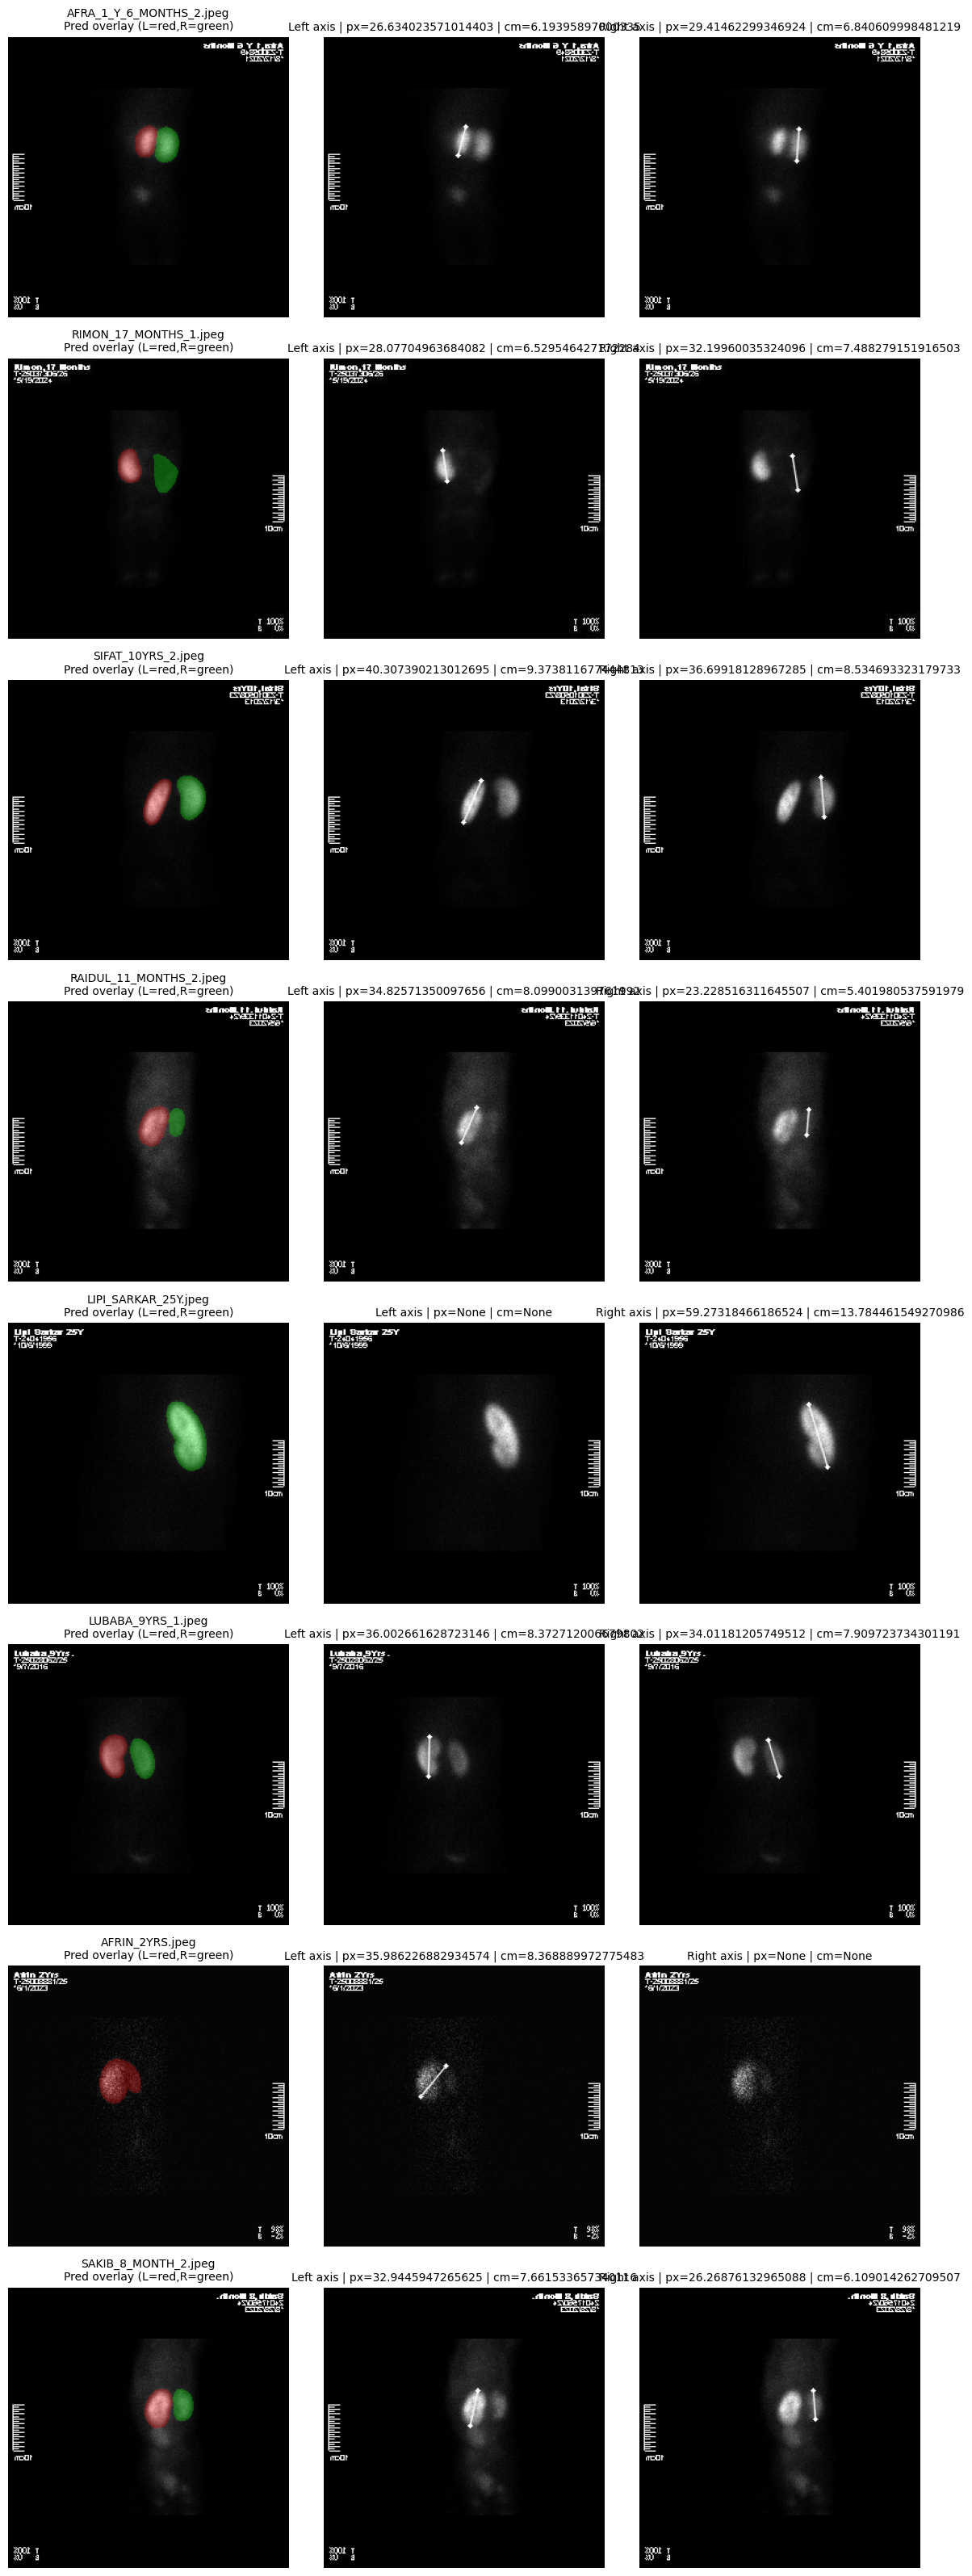

In [42]:
# CELL 35 — ADD NEW CELL (Visual sanity: show predicted mask + major-axis endpoints on a few samples)

def draw_axis_line(img_u8, p1, p2, color=(255,255,255)):
    """
    Draw a line on an RGB image using endpoints p1/p2 (x,y floats).
    """
    out = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    if p1 is not None and p2 is not None:
        x1, y1 = int(round(p1[0])), int(round(p1[1]))
        x2, y2 = int(round(p2[0])), int(round(p2[1]))
        cv2.line(out, (x1,y1), (x2,y2), color, 1, cv2.LINE_AA)
        cv2.circle(out, (x1,y1), 2, color, -1)
        cv2.circle(out, (x2,y2), 2, color, -1)
    return out

def show_measurement_examples(n=8):
    rng = np.random.default_rng(42)
    pick = rng.choice(range(len(meas_df)), size=min(n, len(meas_df)), replace=False).tolist()

    fig, axes = plt.subplots(len(pick), 3, figsize=(12, 4*len(pick)))
    if len(pick) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, k in enumerate(pick):
        rowm = meas_df.iloc[k]
        link = rowm["LINK"]
        base = rowm["basename"]
        view = rowm["VIEW"]

        img_path = resolve_image_path_from_link_strict(link)
        img = load_gray_256(img_path)

        # Standardize view for visualization consistency (same as prediction)
        dummy = np.zeros((256,256), dtype=np.uint8)
        if view is not None:
            img_std, _ = apply_view_standardization(img.copy(), dummy, view)
        else:
            img_std = img

        pred_mask3 = predict_mask3(img, view_value=view)
        pred_mask3 = postprocess_pred_mask3(pred_mask3)

        mL = (pred_mask3 == 1).astype(np.uint8)
        mR = (pred_mask3 == 2).astype(np.uint8)

        lenL_px, L_p1, L_p2 = pca_major_axis_length_px(mL, trim_percent=2.0)
        lenR_px, R_p1, R_p2 = pca_major_axis_length_px(mR, trim_percent=2.0)

        overlay = make_overlay(img_std, pred_mask3)

        img_line_L = draw_axis_line(img_std, L_p1, L_p2)
        img_line_R = draw_axis_line(img_std, R_p1, R_p2)

        axes[r,0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[r,0].set_title(f"{base}\nPred overlay (L=red,R=green)", fontsize=10)
        axes[r,0].axis("off")

        axes[r,1].imshow(cv2.cvtColor(img_line_L, cv2.COLOR_BGR2RGB))
        axes[r,1].set_title(f"Left axis | px={lenL_px} | cm={(lenL_px/PPCM_USED) if lenL_px else None}", fontsize=10)
        axes[r,1].axis("off")

        axes[r,2].imshow(cv2.cvtColor(img_line_R, cv2.COLOR_BGR2RGB))
        axes[r,2].set_title(f"Right axis | px={lenR_px} | cm={(lenR_px/PPCM_USED) if lenR_px else None}", fontsize=10)
        axes[r,2].axis("off")

    plt.tight_layout()
    plt.show()

show_measurement_examples(n=8)


In [43]:
# CELL 36 — ADD NEW CELL (Inspect pred_left_cm / pred_right_cm summary + missing rates)

assert "meas_df" in globals(), "meas_df not found — run Step C measurement cells first."

cols = [
    "basename", "LINK", "VIEW",
    "pred_left_cm", "pred_right_cm",
    "pred_left_len_px", "pred_right_len_px",
    "flag_left_missing", "flag_right_missing", "flag_fused_touch",
    "PPCM_USED"
]

# Keep only columns that exist (safety)
cols = [c for c in cols if c in meas_df.columns]

print("meas_df shape:", meas_df.shape)
print("PPCM_USED unique:", sorted(meas_df["PPCM_USED"].unique().tolist()) if "PPCM_USED" in meas_df.columns else "N/A")

n = len(meas_df)
miss_left = int(meas_df["pred_left_cm"].isna().sum())
miss_right = int(meas_df["pred_right_cm"].isna().sum())

print("\nMissing predictions:")
print(f"  left  missing: {miss_left}/{n} = {miss_left/max(n,1):.3f}")
print(f"  right missing: {miss_right}/{n} = {miss_right/max(n,1):.3f}")

print("\nSummary stats (cm):")
print(meas_df[["pred_left_cm","pred_right_cm"]].describe(percentiles=[0.01,0.05,0.10,0.25,0.5,0.75,0.90,0.95,0.99]).T)

print("\nFirst 15 rows (for quick glance):")
with pd.option_context("display.max_rows", 50, "display.max_colwidth", 140):
    print(meas_df[cols].head(15))


meas_df shape: (2285, 11)
PPCM_USED unique: [4.3]

Missing predictions:
  left  missing: 178/2285 = 0.078
  right missing: 227/2285 = 0.099

Summary stats (cm):
                count      mean       std       min        1%        5%  \
pred_left_cm   2107.0  7.686117  2.050242  1.396630  3.259289  4.820915   
pred_right_cm  2058.0  7.703334  1.912229  1.380094  3.684912  5.101450   

                    10%       25%       50%       75%        90%        95%  \
pred_left_cm   5.523255  6.346553  7.419343  8.762149  10.463201  11.365542   
pred_right_cm  5.525784  6.415065  7.497700  8.770923  10.238586  11.275929   

                     99%        max  
pred_left_cm   13.909293  17.339684  
pred_right_cm  12.791113  16.876205  

First 15 rows (for quick glance):
                      basename                             LINK VIEW  \
0       A_RAHMAN_6_MONTHS.jpeg      Data\A_RAHMAN_6_MONTHS.jpeg    P   
1     A_RAHMAN_6_MONTHS_1.jpeg    Data\A_RAHMAN_6_MONTHS_1.jpeg  LPO   
2     A_RA

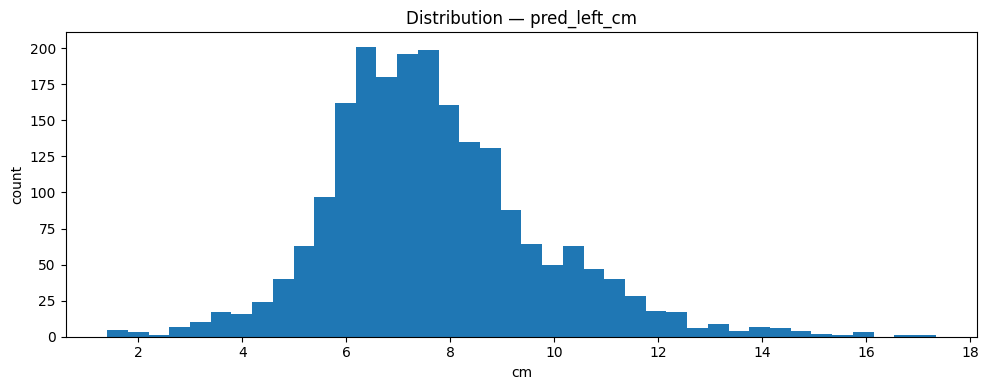

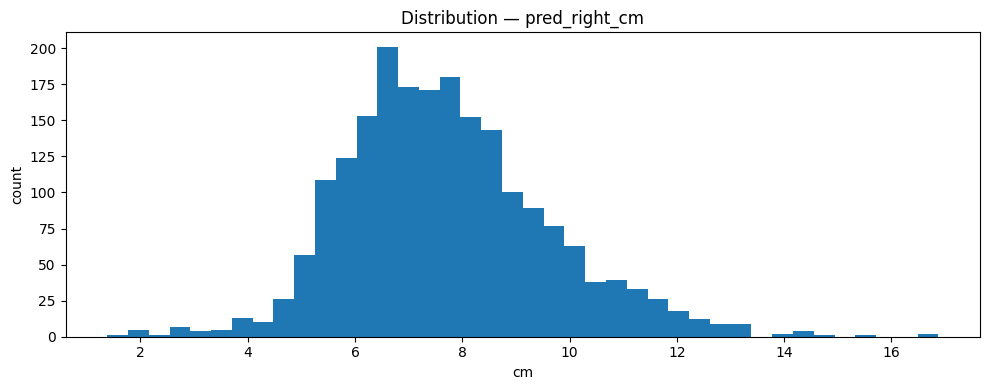

In [44]:
# CELL 37 — ADD NEW CELL (Distributions: histograms for left/right cm)

import matplotlib.pyplot as plt

left = meas_df["pred_left_cm"].dropna().astype(float).values
right = meas_df["pred_right_cm"].dropna().astype(float).values

fig = plt.figure(figsize=(10,4))
plt.hist(left, bins=40)
plt.title("Distribution — pred_left_cm")
plt.xlabel("cm")
plt.ylabel("count")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10,4))
plt.hist(right, bins=40)
plt.title("Distribution — pred_right_cm")
plt.xlabel("cm")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [45]:
# CELL 38 — ADD NEW CELL (Outliers: top/bottom lengths to visually inspect next)

def show_outliers(side="left", k=20):
    assert side in ["left", "right"]
    col = "pred_left_cm" if side == "left" else "pred_right_cm"

    df = meas_df.copy()
    df = df[df[col].notna()].copy()
    df[col] = df[col].astype(float)

    df_small = df.sort_values(col, ascending=True).head(k)
    df_large = df.sort_values(col, ascending=False).head(k)

    keep = ["basename","LINK","VIEW",col,"pred_left_len_px","pred_right_len_px",
            "flag_left_missing","flag_right_missing","flag_fused_touch","PPCM_USED"]
    keep = [c for c in keep if c in df.columns]

    print(f"\n===== {side.upper()} smallest {k} =====")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 140):
        print(df_small[keep])

    print(f"\n===== {side.upper()} largest {k} =====")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 140):
        print(df_large[keep])

show_outliers("left", k=20)
show_outliers("right", k=20)



===== LEFT smallest 20 =====
                           basename                                LINK VIEW  \
1181          MONJURUL_35YRS_1.jpeg          Data\MONJURUL_35YRS_1.jpeg  LPO   
1816           SANJIDA_40_DAYS.jpeg           Data\SANJIDA_40_DAYS.jpeg    P   
98               ABID_7_MONTHS.jpeg             Data\ABID_7_MONTHS.jpeg  RPO   
1584            RIFAT_15_YRS_1.jpeg            Data\RIFAT_15_YRS_1.jpeg  LPO   
1800            SAMIUL_3_YRS_2.jpeg            Data\SAMIUL_3_YRS_2.jpeg  RPO   
740         HOSSAIN_3_MONTHS_2.jpeg        Data\HOSSAIN_3_MONTHS_2.jpeg  RPO   
197      AFRA_SULTANA_02MONTHS.jpeg     Data\AFRA_SULTANA_02MONTHS.jpeg    P   
1450          RABEYA_21_MONTHS.jpeg          Data\RABEYA_21_MONTHS.jpeg    P   
1798              SAMIUL_3_YRS.jpeg              Data\SAMIUL_3_YRS.jpeg    P   
385      ARIYANA_4YRS4MONTHS_1.jpeg     Data\ARIYANA_4YRS4MONTHS_1.jpeg  LPO   
1667             SABID_8_YRS_2.jpeg             Data\SABID_8_YRS_2.jpeg  RPO   
2096      

PHASE 4B starts here

In [56]:
# CELL 39 — FULL REPLACEMENT (Phase-4B: Kidney length chart as MONTH-ONLY bins)

# Convert weeks→months (month ≈ 4.34524 weeks)
WEEKS_PER_MONTH = 4.34524

def weeks_to_months(w):
    return float(w) / WEEKS_PER_MONTH

# Build month-only bins:
# Store: [min_months, max_months) with mean/sd
# Last bin is open-ended (18+ years) => max_months=None

RENAL_LEN_BINS = [
    # 0–1 week  -> months
    {"label": f"{0.0:.3f}-{weeks_to_months(1.0):.3f} mo", "min_months": 0.0,                 "max_months": weeks_to_months(1.0), "mean_cm": 4.5,  "sd_cm": 0.3},

    # 1 week–4 months -> months
    {"label": f"{weeks_to_months(1.0):.3f}-4.000 mo",     "min_months": weeks_to_months(1.0), "max_months": 4.0,                 "mean_cm": 5.3,  "sd_cm": 0.7},

    # month bins
    {"label": "4.000-8.000 mo",    "min_months": 4.0,   "max_months": 8.0,   "mean_cm": 6.2,  "sd_cm": 0.7},
    {"label": "8.000-12.000 mo",   "min_months": 8.0,   "max_months": 12.0,  "mean_cm": 6.2,  "sd_cm": 0.6},

    # year bins expressed as months
    {"label": "12.000-24.000 mo",  "min_months": 12.0,  "max_months": 24.0,  "mean_cm": 6.6,  "sd_cm": 0.5},
    {"label": "24.000-36.000 mo",  "min_months": 24.0,  "max_months": 36.0,  "mean_cm": 7.4,  "sd_cm": 0.5},
    {"label": "36.000-48.000 mo",  "min_months": 36.0,  "max_months": 48.0,  "mean_cm": 7.4,  "sd_cm": 0.6},
    {"label": "48.000-60.000 mo",  "min_months": 48.0,  "max_months": 60.0,  "mean_cm": 7.9,  "sd_cm": 0.5},
    {"label": "60.000-72.000 mo",  "min_months": 60.0,  "max_months": 72.0,  "mean_cm": 8.1,  "sd_cm": 0.5},
    {"label": "72.000-84.000 mo",  "min_months": 72.0,  "max_months": 84.0,  "mean_cm": 7.8,  "sd_cm": 0.7},
    {"label": "84.000-96.000 mo",  "min_months": 84.0,  "max_months": 96.0,  "mean_cm": 8.3,  "sd_cm": 0.5},
    {"label": "96.000-108.000 mo", "min_months": 96.0,  "max_months": 108.0, "mean_cm": 8.9,  "sd_cm": 0.9},
    {"label": "108.000-120.000 mo","min_months": 108.0, "max_months": 120.0, "mean_cm": 9.2,  "sd_cm": 0.9},
    {"label": "120.000-132.000 mo","min_months": 120.0, "max_months": 132.0, "mean_cm": 9.2,  "sd_cm": 0.8},
    {"label": "132.000-144.000 mo","min_months": 132.0, "max_months": 144.0, "mean_cm": 9.6,  "sd_cm": 0.6},
    {"label": "144.000-156.000 mo","min_months": 144.0, "max_months": 156.0, "mean_cm": 10.4, "sd_cm": 0.9},
    {"label": "156.000-168.000 mo","min_months": 156.0, "max_months": 168.0, "mean_cm": 9.8,  "sd_cm": 0.8},
    {"label": "168.000-180.000 mo","min_months": 168.0, "max_months": 180.0, "mean_cm": 10.0, "sd_cm": 0.6},
    {"label": "180.000-192.000 mo","min_months": 180.0, "max_months": 192.0, "mean_cm": 11.0, "sd_cm": 0.8},
    {"label": "192.000-204.000 mo","min_months": 192.0, "max_months": 204.0, "mean_cm": 10.0, "sd_cm": 0.9},
    {"label": "204.000-216.000 mo","min_months": 204.0, "max_months": 216.0, "mean_cm": 10.5, "sd_cm": 0.3},

    # 18+ years -> 216 months and above (open-ended)
    {"label": "216.000+ mo",       "min_months": 216.0, "max_months": None,  "mean_cm": 10.8, "sd_cm": 1.1},
]

bins_df = pd.DataFrame(RENAL_LEN_BINS)
print("Bins:", len(bins_df))
print(bins_df)

print("\nConversion proof:")
print("1 week =", weeks_to_months(1.0), "months")


Bins: 22
                 label  min_months  max_months  mean_cm  sd_cm
0       0.000-0.230 mo    0.000000    0.230137      4.5    0.3
1       0.230-4.000 mo    0.230137    4.000000      5.3    0.7
2       4.000-8.000 mo    4.000000    8.000000      6.2    0.7
3      8.000-12.000 mo    8.000000   12.000000      6.2    0.6
4     12.000-24.000 mo   12.000000   24.000000      6.6    0.5
5     24.000-36.000 mo   24.000000   36.000000      7.4    0.5
6     36.000-48.000 mo   36.000000   48.000000      7.4    0.6
7     48.000-60.000 mo   48.000000   60.000000      7.9    0.5
8     60.000-72.000 mo   60.000000   72.000000      8.1    0.5
9     72.000-84.000 mo   72.000000   84.000000      7.8    0.7
10    84.000-96.000 mo   84.000000   96.000000      8.3    0.5
11   96.000-108.000 mo   96.000000  108.000000      8.9    0.9
12  108.000-120.000 mo  108.000000  120.000000      9.2    0.9
13  120.000-132.000 mo  120.000000  132.000000      9.2    0.8
14  132.000-144.000 mo  132.000000  144.000000

In [57]:
# CELL 40 — FULL REPLACEMENT (Phase-4B: Age in months — use existing CSV column)

# IMPORTANT: We do NOT invent column names.
# Your CSV already contains this exact column:
COL_AGE_MONTHS = "AGE in MONTHS"

assert COL_AGE_MONTHS in df_use.columns, f"Missing required column: {COL_AGE_MONTHS}"

def get_age_months_for_row(row):
    """
    Uses the existing 'AGE in MONTHS' column from the CSV.
    Returns float age_months (or None if invalid).
    """
    v = row[COL_AGE_MONTHS]
    if pd.isna(v):
        return None
    try:
        return float(v)
    except Exception:
        return None

print("OK — Using CSV column for age months:", COL_AGE_MONTHS)
print("Example values:", df_use[COL_AGE_MONTHS].head(10).tolist())


OK — Using CSV column for age months: AGE in MONTHS
Example values: [6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 756.0, 756.0, 756.0, 84.0]


In [58]:
# CELL 41 — FULL REPLACEMENT (Phase-4B: Lookup expected mean/sd by MONTH-ONLY bins)

def lookup_chart_by_age_bin(age_months):
    """
    Uses RENAL_LEN_BINS (month-only).
    Returns dict:
      {bin_label, bin_min_months, bin_max_months, mean_cm, sd_cm, out_of_chart}
    """
    if age_months is None or pd.isna(age_months):
        return {"bin_label": None, "bin_min_months": None, "bin_max_months": None,
                "mean_cm": None, "sd_cm": None, "out_of_chart": True}

    try:
        a = float(age_months)
    except Exception:
        return {"bin_label": None, "bin_min_months": None, "bin_max_months": None,
                "mean_cm": None, "sd_cm": None, "out_of_chart": True}

    if a < 0:
        return {"bin_label": None, "bin_min_months": None, "bin_max_months": None,
                "mean_cm": None, "sd_cm": None, "out_of_chart": True}

    for b in RENAL_LEN_BINS:
        lo = float(b["min_months"])
        hi = b["max_months"]
        if hi is None:
            if a >= lo:
                return {"bin_label": b["label"], "bin_min_months": lo, "bin_max_months": None,
                        "mean_cm": float(b["mean_cm"]), "sd_cm": float(b["sd_cm"]), "out_of_chart": False}
        else:
            hi = float(hi)
            if (a >= lo) and (a < hi):
                return {"bin_label": b["label"], "bin_min_months": lo, "bin_max_months": hi,
                        "mean_cm": float(b["mean_cm"]), "sd_cm": float(b["sd_cm"]), "out_of_chart": False}

    return {"bin_label": None, "bin_min_months": None, "bin_max_months": None,
            "mean_cm": None, "sd_cm": None, "out_of_chart": True}

# quick checks (all in months)
for a in [0.1, weeks_to_months(1.0), 2.0, 6.0, 11.9, 12.0, 215.9, 216.0, 500.0]:
    print(a, "months =>", lookup_chart_by_age_bin(a))


0.1 months => {'bin_label': '0.000-0.230 mo', 'bin_min_months': 0.0, 'bin_max_months': 0.23013688541944746, 'mean_cm': 4.5, 'sd_cm': 0.3, 'out_of_chart': False}
0.23013688541944746 months => {'bin_label': '0.230-4.000 mo', 'bin_min_months': 0.23013688541944746, 'bin_max_months': 4.0, 'mean_cm': 5.3, 'sd_cm': 0.7, 'out_of_chart': False}
2.0 months => {'bin_label': '0.230-4.000 mo', 'bin_min_months': 0.23013688541944746, 'bin_max_months': 4.0, 'mean_cm': 5.3, 'sd_cm': 0.7, 'out_of_chart': False}
6.0 months => {'bin_label': '4.000-8.000 mo', 'bin_min_months': 4.0, 'bin_max_months': 8.0, 'mean_cm': 6.2, 'sd_cm': 0.7, 'out_of_chart': False}
11.9 months => {'bin_label': '8.000-12.000 mo', 'bin_min_months': 8.0, 'bin_max_months': 12.0, 'mean_cm': 6.2, 'sd_cm': 0.6, 'out_of_chart': False}
12.0 months => {'bin_label': '12.000-24.000 mo', 'bin_min_months': 12.0, 'bin_max_months': 24.0, 'mean_cm': 6.6, 'sd_cm': 0.5, 'out_of_chart': False}
215.9 months => {'bin_label': '204.000-216.000 mo', 'bin_m

In [59]:
# CELL 42 — FULL REPLACEMENT (Phase-4B: Create SIZE category predictions using AGE in MONTHS + bin lookup)

from tqdm import tqdm

assert "meas_df" in globals(), "meas_df not found — run Phase-4A Step C to produce meas_df first."
assert "df_use" in globals(), "df_use not found — CSV dataframe missing."

COL_AGE_MONTHS = "AGE in MONTHS"
assert COL_AGE_MONTHS in df_use.columns, f"Missing required column: {COL_AGE_MONTHS}"

df_use_by_link = df_use.set_index(cfg.COL_LINK, drop=False)

def get_age_months_for_row(row):
    v = row[COL_AGE_MONTHS]
    if pd.isna(v):
        return None
    try:
        return float(v)
    except Exception:
        return None

def cm_to_size_label(cm, mean_cm, sd_cm):
    """
    3-class: SMALL / NORMAL / BIGGER based on Mean±SD of the age-bin.
    """
    if cm is None or pd.isna(cm) or mean_cm is None or sd_cm is None:
        return None
    x = float(cm)
    mu = float(mean_cm)
    sd = float(sd_cm)

    if x < (mu - sd):
        return "SMALL"
    if x > (mu + sd):
        return "BIGGER"
    return "NORMAL"

rows_out = []

print("Building size categories using AGE bins (progress below):")
for i in tqdm(range(len(meas_df))):
    r = meas_df.iloc[i]
    link = r["LINK"]

    if link not in df_use_by_link.index:
        age_months = None
        chart = lookup_chart_by_age_bin(None)
    else:
        src = df_use_by_link.loc[link]
        age_months = get_age_months_for_row(src)
        chart = lookup_chart_by_age_bin(age_months)

    L_cm = r["pred_left_cm"]
    R_cm = r["pred_right_cm"]

    pred_size_left = cm_to_size_label(L_cm, chart["mean_cm"], chart["sd_cm"])
    pred_size_right = cm_to_size_label(R_cm, chart["mean_cm"], chart["sd_cm"])

    rows_out.append({
        "LINK": link,
        "basename": r.get("basename", None),
        "VIEW": r.get("VIEW", None),

        "age_months_parsed": age_months,
        "age_bin_label": chart["bin_label"],
        "expected_mean_cm": chart["mean_cm"],
        "expected_sd_cm": chart["sd_cm"],
        "flag_age_out_of_chart": chart["out_of_chart"],

        # internal cm (audit)
        "pred_left_cm": L_cm,
        "pred_right_cm": R_cm,

        # final intended output later
        "pred_SIZE_LEFT": pred_size_left,
        "pred_SIZE_RIGHT": pred_size_right,

        # QC flags
        "flag_left_missing": r.get("flag_left_missing", None),
        "flag_right_missing": r.get("flag_right_missing", None),
        "flag_fused_touch": r.get("flag_fused_touch", None),
        "PPCM_USED": r.get("PPCM_USED", None),
    })

size_pred_df = pd.DataFrame(rows_out)
print("size_pred_df:", size_pred_df.shape)
print(size_pred_df.head(10))


Building size categories using AGE bins (progress below):


100%|██████████| 2285/2285 [00:00<00:00, 12572.77it/s]


size_pred_df: (2285, 16)
                              LINK                    basename VIEW  \
0      Data\A_RAHMAN_6_MONTHS.jpeg      A_RAHMAN_6_MONTHS.jpeg    P   
1    Data\A_RAHMAN_6_MONTHS_1.jpeg    A_RAHMAN_6_MONTHS_1.jpeg  LPO   
2    Data\A_RAHMAN_6_MONTHS_2.jpeg    A_RAHMAN_6_MONTHS_2.jpeg  RPO   
3    Data\ABDUL_ALIM_1_MONTHS.jpeg    ABDUL_ALIM_1_MONTHS.jpeg    P   
4  Data\ABDUL_ALIM_1_MONTHS_1.jpeg  ABDUL_ALIM_1_MONTHS_1.jpeg  LPO   
5  Data\ABDUL_ALIM_1_MONTHS_2.jpeg  ABDUL_ALIM_1_MONTHS_2.jpeg  RPO   
6     Data\ABDUL_BATIN_63_YRS.jpeg     ABDUL_BATIN_63_YRS.jpeg    P   
7   Data\ABDUL_BATIN_63_YRS_1.jpeg   ABDUL_BATIN_63_YRS_1.jpeg  LPO   
8   Data\ABDUL_BATIN_63_YRS_2.jpeg   ABDUL_BATIN_63_YRS_2.jpeg  RPO   
9    Data\ABDUL_MOTALIB_7_YRS.jpeg    ABDUL_MOTALIB_7_YRS.jpeg    P   

   age_months_parsed     age_bin_label  expected_mean_cm  expected_sd_cm  \
0                6.0    4.000-8.000 mo               6.2             0.7   
1                6.0    4.000-8.000 mo   

In [60]:
# CELL 43 — ADD NEW CELL (Save Phase-4B mapping output to NEW CSV)

OUT_4B = cfg.BASE_DIR / "phase4B_size_category_predictions.csv"
size_pred_df.to_csv(OUT_4B, index=False)
print("Saved:", OUT_4B)


Saved: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4B_size_category_predictions.csv


In [61]:
# CELL 44 — FULL REPLACEMENT (Summaries: bin counts + size counts + out_of_chart)

def _vc(s):
    return s.value_counts(dropna=False)

print("\nAge bin label counts:")
print(_vc(size_pred_df["age_bin_label"]))

print("\nOut-of-chart (invalid age) count:")
print(int(size_pred_df["flag_age_out_of_chart"].sum()), "/", len(size_pred_df))

print("\nPred SIZE LEFT counts:")
print(_vc(size_pred_df["pred_SIZE_LEFT"]))

print("\nPred SIZE RIGHT counts:")
print(_vc(size_pred_df["pred_SIZE_RIGHT"]))

print("\nSide missing flags:")
print("  left missing :", int(size_pred_df["flag_left_missing"].sum()) if "flag_left_missing" in size_pred_df.columns else "N/A")
print("  right missing:", int(size_pred_df["flag_right_missing"].sum()) if "flag_right_missing" in size_pred_df.columns else "N/A")
print("  fused-touch  :", int(size_pred_df["flag_fused_touch"].sum()) if "flag_fused_touch" in size_pred_df.columns else "N/A")



Age bin label counts:
age_bin_label
216.000+ mo           267
12.000-24.000 mo      256
24.000-36.000 mo      229
48.000-60.000 mo      182
36.000-48.000 mo      154
0.230-4.000 mo        150
4.000-8.000 mo        145
8.000-12.000 mo       132
60.000-72.000 mo      112
108.000-120.000 mo     99
84.000-96.000 mo       91
72.000-84.000 mo       88
96.000-108.000 mo      85
120.000-132.000 mo     63
132.000-144.000 mo     63
144.000-156.000 mo     54
192.000-204.000 mo     30
168.000-180.000 mo     24
156.000-168.000 mo     21
204.000-216.000 mo     19
180.000-192.000 mo     18
0.000-0.230 mo          3
Name: count, dtype: int64

Out-of-chart (invalid age) count:
0 / 2285

Pred SIZE LEFT counts:
pred_SIZE_LEFT
NORMAL    824
SMALL     788
BIGGER    495
None      178
Name: count, dtype: int64

Pred SIZE RIGHT counts:
pred_SIZE_RIGHT
NORMAL    791
SMALL     758
BIGGER    509
None      227
Name: count, dtype: int64

Side missing flags:
  left missing : 173
  right missing: 217
  fused-touch 

In [62]:
# CELL 45 — ADD NEW CELL (Phase-4B: Outlier inspection tables — SMALL/BIGGER extremes + missing/fused)

from tqdm import tqdm

assert "size_pred_df" in globals(), "size_pred_df not found — run Phase-4B cells first."

# Helper: safely cast to float
def _to_float_series(s):
    return pd.to_numeric(s, errors="coerce")

def show_size_extremes(side="LEFT", k=20):
    """
    side: 'LEFT' or 'RIGHT'
    Prints:
      - BIGGER: top-k largest cm where pred_SIZE_* == 'BIGGER'
      - SMALL : top-k smallest cm where pred_SIZE_* == 'SMALL'
      - Also shows missing/fused flags and age bin.
    """
    assert side in ["LEFT", "RIGHT"]

    cm_col = "pred_left_cm" if side == "LEFT" else "pred_right_cm"
    size_col = "pred_SIZE_LEFT" if side == "LEFT" else "pred_SIZE_RIGHT"

    df = size_pred_df.copy()
    df[cm_col] = _to_float_series(df[cm_col])

    keep = [
        "LINK", "basename", "VIEW",
        "age_months_parsed", "age_bin_label",
        "expected_mean_cm", "expected_sd_cm",
        cm_col, size_col,
        "flag_left_missing", "flag_right_missing", "flag_fused_touch",
        "PPCM_USED"
    ]
    keep = [c for c in keep if c in df.columns]

    df_bigger = df[(df[size_col] == "BIGGER") & df[cm_col].notna()].copy()
    df_small  = df[(df[size_col] == "SMALL")  & df[cm_col].notna()].copy()

    df_bigger = df_bigger.sort_values(cm_col, ascending=False).head(k)
    df_small  = df_small.sort_values(cm_col, ascending=True).head(k)

    print(f"\n==================== {side} — BIGGER (top {k} by {cm_col}) ====================")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
        print(df_bigger[keep])

    print(f"\n==================== {side} — SMALL (bottom {k} by {cm_col}) ====================")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
        print(df_small[keep])

print("Outlier inspection: extremes for LEFT and RIGHT")
show_size_extremes("LEFT", k=20)
show_size_extremes("RIGHT", k=20)
print("\nDONE.")


Outlier inspection: extremes for LEFT and RIGHT

==================== LEFT — BIGGER (top 20 by pred_left_cm) ====================
                                     LINK                        basename  \
2232       Data\ZAHID_HASAN_11_YRS_1.jpeg       ZAHID_HASAN_11_YRS_1.jpeg   
2231         Data\ZAHID_HASAN_11_YRS.jpeg         ZAHID_HASAN_11_YRS.jpeg   
490   Data\BABY_ABDULLAH_19_MONTHS_1.jpeg  BABY_ABDULLAH_19_MONTHS_1.jpeg   
491   Data\BABY_ABDULLAH_19_MONTHS_2.jpeg  BABY_ABDULLAH_19_MONTHS_2.jpeg   
489     Data\BABY_ABDULLAH_19_MONTHS.jpeg    BABY_ABDULLAH_19_MONTHS.jpeg   
193               Data\AFFAN_6_YRS_2.jpeg              AFFAN_6_YRS_2.jpeg   
1035              Data\MAHIN_05YRS_2.jpeg              MAHIN_05YRS_2.jpeg   
1741             Data\SAIMON_3_YRS_1.jpeg             SAIMON_3_YRS_1.jpeg   
1889     Data\SHAMSUL_HAQUE_62_YRS_1.jpeg     SHAMSUL_HAQUE_62_YRS_1.jpeg   
1888       Data\SHAMSUL_HAQUE_62_YRS.jpeg       SHAMSUL_HAQUE_62_YRS.jpeg   
553          Data\DIN_I

In [63]:
# CELL 46 — ADD NEW CELL (Phase-4B: Category vs flags summary — how much of BIGGER/SMALL is driven by missing/fused)

assert "size_pred_df" in globals(), "size_pred_df not found — run Phase-4B cells first."

def summarize_flags_by_category(side="LEFT"):
    assert side in ["LEFT", "RIGHT"]
    size_col = "pred_SIZE_LEFT" if side == "LEFT" else "pred_SIZE_RIGHT"

    df = size_pred_df.copy()

    # Ensure flags are boolean-like where possible
    for f in ["flag_left_missing", "flag_right_missing", "flag_fused_touch"]:
        if f in df.columns:
            df[f] = df[f].fillna(False).astype(bool)

    cats = ["SMALL", "NORMAL", "BIGGER", None, np.nan]

    rows = []
    for cat in ["SMALL", "NORMAL", "BIGGER", None]:
        if cat is None:
            sub = df[df[size_col].isna()]
            cat_name = "None"
        else:
            sub = df[df[size_col] == cat]
            cat_name = cat

        n = len(sub)
        if n == 0:
            rows.append({
                "side": side, "category": cat_name, "n": 0,
                "pct_left_missing": None, "pct_right_missing": None, "pct_fused_touch": None
            })
            continue

        pct_Lm = (sub["flag_left_missing"].mean() * 100.0) if "flag_left_missing" in sub.columns else None
        pct_Rm = (sub["flag_right_missing"].mean() * 100.0) if "flag_right_missing" in sub.columns else None
        pct_F  = (sub["flag_fused_touch"].mean() * 100.0) if "flag_fused_touch" in sub.columns else None

        rows.append({
            "side": side,
            "category": cat_name,
            "n": n,
            "pct_left_missing": round(pct_Lm, 2) if pct_Lm is not None else None,
            "pct_right_missing": round(pct_Rm, 2) if pct_Rm is not None else None,
            "pct_fused_touch": round(pct_F, 2) if pct_F is not None else None,
        })

    out = pd.DataFrame(rows)
    return out

left_sum = summarize_flags_by_category("LEFT")
right_sum = summarize_flags_by_category("RIGHT")

print("LEFT category vs flags:")
print(left_sum)

print("\nRIGHT category vs flags:")
print(right_sum)
print("\nDONE.")


LEFT category vs flags:
   side category    n  pct_left_missing  pct_right_missing  pct_fused_touch
0  LEFT    SMALL  788              0.00               3.43            18.91
1  LEFT   NORMAL  824              0.00              13.47            22.94
2  LEFT   BIGGER  495              0.00              15.96            28.08
3  LEFT     None  178             97.19               0.00             1.12

RIGHT category vs flags:
    side category    n  pct_left_missing  pct_right_missing  pct_fused_touch
0  RIGHT    SMALL  758              2.24               0.00            22.96
1  RIGHT   NORMAL  791             11.76               0.00            19.60
2  RIGHT   BIGGER  509             12.38               0.00            28.68
3  RIGHT     None  227              0.00              95.59             1.76

DONE.


In [64]:
# CELL 47 — ADD NEW CELL (Phase-4B: Bin-level sanity — size category distribution per age_bin_label)

assert "size_pred_df" in globals(), "size_pred_df not found — run Phase-4B cells first."

# Only keep bins with enough samples to be meaningful
MIN_N = 20

def bin_category_table(side="LEFT"):
    size_col = "pred_SIZE_LEFT" if side == "LEFT" else "pred_SIZE_RIGHT"
    df = size_pred_df.copy()

    # Count total per bin
    bin_counts = df["age_bin_label"].value_counts(dropna=False)
    valid_bins = bin_counts[bin_counts >= MIN_N].index.tolist()

    sub = df[df["age_bin_label"].isin(valid_bins)].copy()

    # Crosstab with percentages
    ct = pd.crosstab(sub["age_bin_label"], sub[size_col], dropna=False)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100.0

    return ct, ct_pct

ctL, ctL_pct = bin_category_table("LEFT")
ctR, ctR_pct = bin_category_table("RIGHT")

print("LEFT: category counts per bin (bins with n>=20):")
print(ctL)

print("\nLEFT: category % per bin (bins with n>=20):")
print(ctL_pct.round(2))

print("\nRIGHT: category counts per bin (bins with n>=20):")
print(ctR)

print("\nRIGHT: category % per bin (bins with n>=20):")
print(ctR_pct.round(2))

print("\nDONE.")


LEFT: category counts per bin (bins with n>=20):
pred_SIZE_LEFT      BIGGER  NORMAL  SMALL  NaN
age_bin_label                                 
0.230-4.000 mo          54      63     11   22
108.000-120.000 mo       4      38     48    9
12.000-24.000 mo        78      88     69   21
120.000-132.000 mo      11      16     30    6
132.000-144.000 mo      12      20     31    0
144.000-156.000 mo       5      11     38    0
156.000-168.000 mo       6       2      7    6
168.000-180.000 mo      12       3      6    3
192.000-204.000 mo       7      11     11    1
216.000+ mo             27     115    103   22
24.000-36.000 mo        46      70     96   17
36.000-48.000 mo        39      54     52    9
4.000-8.000 mo          38      72     29    6
48.000-60.000 mo        31      42     91   18
60.000-72.000 mo        22      45     35   10
72.000-84.000 mo        29      35     18    6
8.000-12.000 mo         41      57     22   12
84.000-96.000 mo        20      24     42    5
96.000-108.

In [65]:
# CELL 48 — ADD NEW CELL (Phase-4B: Multi-task SIZE heads setup — no chart dependency)

# We will train SIZE LEFT + SIZE RIGHT as heads in the SAME multi-task CNN.
# Phase-4A masks are used only to optionally create masked-image inputs.

COL_SIZE_L = "SIZE LEFT"
COL_SIZE_R = "SIZE RIGHT"
COL_SCAR   = "SCAR"
COL_UP_L   = "CORTICAL UPTAKE LEFT"
COL_UP_R   = "CORTICAL UPTAKE RIGHT"

# Confirm required columns exist (NO renaming)
need_cols = [
    cfg.COL_PATIENT, cfg.COL_LINK, cfg.COL_VIEW,
    cfg.COL_COUNT, cfg.COL_ANATOMY, cfg.COL_POSITION,
    COL_SCAR, COL_UP_L, COL_UP_R, COL_SIZE_L, COL_SIZE_R
]
missing_cols = [c for c in need_cols if c not in df_use.columns]
assert len(missing_cols) == 0, f"Missing columns in df_use: {missing_cols}"

# Use masks to create kidney-only input (recommended by you)
USE_MASKED_INPUT = True  # multiplies image by union(left,right) mask from JSON (after VIEW flip)

# Training hyperparams (small dataset safe defaults)
MT_SEED = 42
MT_BATCH = 16
MT_EPOCHS = 12
MT_LR = 3e-5
MT_WD = 1e-4
MT_PATIENCE = 4

# Phase-3 checkpoint filename (from your Phase-3 notebook run_info)
PHASE3_CKPT_NAME = "phase3_best.pt"
PHASE3_CKPT_PATH = cfg.BASE_DIR / PHASE3_CKPT_NAME
assert PHASE3_CKPT_PATH.exists(), f"Phase-3 ckpt not found: {PHASE3_CKPT_PATH}"

# Heads are equally important (your rule) — equal weights by default
W = {
    "count": 1.0,
    "anatomy": 1.0,
    "position": 1.0,
    "scar": 1.0,
    "up_l": 1.0,
    "up_r": 1.0,
    "size_l": 1.0,
    "size_r": 1.0,
}

print("Phase-4B (SIZE heads) config OK")
print("USE_MASKED_INPUT:", USE_MASKED_INPUT)
print("PHASE3_CKPT_PATH:", PHASE3_CKPT_PATH)
print("Weights:", W)


Phase-4B (SIZE heads) config OK
USE_MASKED_INPUT: True
PHASE3_CKPT_PATH: F:\Bracu\THESIS\Final Defence\Dataset\code\phase3_best.pt
Weights: {'count': 1.0, 'anatomy': 1.0, 'position': 1.0, 'scar': 1.0, 'up_l': 1.0, 'up_r': 1.0, 'size_l': 1.0, 'size_r': 1.0}


In [66]:
# CELL 49 — ADD NEW CELL (Phase-4B: Build df_mt for training — already dropped BRA + your drop-name list)

df_mt = df_use.copy().reset_index(drop=True)

# Sanity: count should be only {1,2} because BRA/0-kidney was dropped earlier
df_mt[cfg.COL_COUNT] = df_mt[cfg.COL_COUNT].astype(int)
bad = df_mt[~df_mt[cfg.COL_COUNT].isin([1,2])]
assert len(bad) == 0, f"Found Kidney COUNT outside {{1,2}} in df_mt. Examples:\n{bad[[cfg.COL_PATIENT,cfg.COL_LINK,cfg.COL_COUNT]].head(5)}"

# Ensure no missing labels (you said CSV is fully labeled)
chk_cols = [cfg.COL_LINK, cfg.COL_VIEW, cfg.COL_COUNT, cfg.COL_ANATOMY, cfg.COL_POSITION,
            COL_SCAR, COL_UP_L, COL_UP_R, COL_SIZE_L, COL_SIZE_R]
for c in chk_cols:
    assert df_mt[c].isna().sum() == 0, f"Unexpected NaNs in df_mt column: {c}"

print("df_mt shape:", df_mt.shape)
print("Kidney COUNT counts:\n", df_mt[cfg.COL_COUNT].value_counts())
print("ANATOMY counts:\n", df_mt[cfg.COL_ANATOMY].astype(str).value_counts().head(10))
print("POSITION counts:\n", df_mt[cfg.COL_POSITION].astype(str).value_counts())
print("SCAR counts:\n", df_mt[COL_SCAR].astype(str).value_counts())


df_mt shape: (2285, 25)
Kidney COUNT counts:
 Kidney COUNT
2    1842
1     443
Name: count, dtype: int64
ANATOMY counts:
 ANATOMY
NORMAL     1660
SINGLE      437
ECTOPIC     152
HORSHOE      36
Name: count, dtype: int64
POSITION counts:
 POSITION
NORMAL RENAL FOSSA    2094
ECTOPIC                191
Name: count, dtype: int64
SCAR counts:
 SCAR
NO     2051
YES     234
Name: count, dtype: int64


In [67]:
# CELL 50 — ADD NEW CELL (Phase-4B: Label encoders for all categorical heads — include NOT APPLICABLE as a real class)

def norm_str(s):
    return str(s).strip().upper()

# Categorical heads (CrossEntropy)
classes_anat   = sorted(df_mt[cfg.COL_ANATOMY].map(norm_str).unique().tolist())
classes_pos    = sorted(df_mt[cfg.COL_POSITION].map(norm_str).unique().tolist())

# NOT APPLICABLE stays as a real class (medically meaningful)
classes_up_l   = sorted(df_mt[COL_UP_L].map(norm_str).unique().tolist())
classes_up_r   = sorted(df_mt[COL_UP_R].map(norm_str).unique().tolist())

classes_size_l = sorted(df_mt[COL_SIZE_L].map(norm_str).unique().tolist())
classes_size_r = sorted(df_mt[COL_SIZE_R].map(norm_str).unique().tolist())

anat2idx   = {c:i for i,c in enumerate(classes_anat)}
pos2idx    = {c:i for i,c in enumerate(classes_pos)}
upl2idx    = {c:i for i,c in enumerate(classes_up_l)}
upr2idx    = {c:i for i,c in enumerate(classes_up_r)}
sizel2idx  = {c:i for i,c in enumerate(classes_size_l)}
sizer2idx  = {c:i for i,c in enumerate(classes_size_r)}

NUM_ANAT   = len(classes_anat)
NUM_POS    = len(classes_pos)
NUM_UP_L   = len(classes_up_l)
NUM_UP_R   = len(classes_up_r)
NUM_SIZE_L = len(classes_size_l)
NUM_SIZE_R = len(classes_size_r)

def count_to_bin(v):
    # output: 0 for 1-kidney, 1 for 2-kidney
    v = int(v)
    assert v in [1,2]
    return 1 if v == 2 else 0

def scar_to_bin(s):
    v = norm_str(s)
    if v == "YES":
        return 1
    if v == "NO":
        return 0
    raise ValueError(f"Unexpected SCAR label: {s}")

print("Class vocab sizes:")
print("  ANATOMY:", NUM_ANAT, classes_anat)
print("  POSITION:", NUM_POS, classes_pos)
print("  UPTAKE L:", NUM_UP_L, classes_up_l)
print("  UPTAKE R:", NUM_UP_R, classes_up_r)
print("  SIZE L:", NUM_SIZE_L, classes_size_l)
print("  SIZE R:", NUM_SIZE_R, classes_size_r)


Class vocab sizes:
  ANATOMY: 4 ['ECTOPIC', 'HORSHOE', 'NORMAL', 'SINGLE']
  POSITION: 2 ['ECTOPIC', 'NORMAL RENAL FOSSA']
  UPTAKE L: 3 ['NORMAL', 'NOT APPLICABLE', 'REDUCED']
  UPTAKE R: 3 ['NORMAL', 'NOT APPLICABLE', 'REDUCED']
  SIZE L: 5 ['BIGGER', 'NORMAL', 'NV', 'PO', 'SMALLER']
  SIZE R: 5 ['BIGGER', 'NORMAL', 'NV', 'PO', 'SMALLER']


In [68]:
# CELL 51 — ADD NEW CELL (Phase-4B: Multi-task Dataset — strict LINK loading + VIEW flip + optional mask)

from torch.utils.data import Dataset, DataLoader

def get_union_mask_u8_from_row(row):
    """
    Union mask (left ∪ right) from your JSON polygons.
    Must match the same VIEW standardization used for the image.
    """
    link = row[cfg.COL_LINK]
    base = _basename_from_link(link)

    mask3, ml, mr = build_lr_mask_3class(base)

    union = ((ml > 0) | (mr > 0)).astype(np.uint8) * 255

    # Apply same VIEW flip rule you used everywhere else
    if "VIEW" in row.index:
        _, union = apply_view_standardization(np.zeros((256,256), dtype=np.uint8), union, row["VIEW"])
        # apply_view_standardization flips img and mask; we pass dummy img to reuse exact logic

    return union

class DMSAMultiTaskDataset(Dataset):
    def __init__(self, df_in):
        self.df = df_in.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        link = row[cfg.COL_LINK]
        img_path = resolve_image_path_from_link_strict(link)
        img = load_gray_256(img_path)  # uint8 (256,256)

        # Get union mask if requested and available in JSON
        if USE_MASKED_INPUT:
            base = _basename_from_link(link)
            if base in json_key_set:
                union = get_union_mask_u8_from_row(row)  # uint8 0/255
                img = (img.astype(np.float32) * (union > 0).astype(np.float32)).astype(np.uint8)

        # Apply VIEW standardization (flip) consistently
        if "VIEW" in row.index:
            img, _ = apply_view_standardization(img, np.zeros((256,256), dtype=np.uint8), row["VIEW"])

        # to tensor float [0,1]
        x = (img.astype(np.float32) / 255.0)
        x = torch.from_numpy(x).unsqueeze(0).float()

        # Targets
        y = {
            "count": torch.tensor(count_to_bin(row[cfg.COL_COUNT]), dtype=torch.float32),  # BCE
            "scar": torch.tensor(scar_to_bin(row[COL_SCAR]), dtype=torch.float32),        # BCE

            "anatomy": torch.tensor(anat2idx[norm_str(row[cfg.COL_ANATOMY])], dtype=torch.long),
            "position": torch.tensor(pos2idx[norm_str(row[cfg.COL_POSITION])], dtype=torch.long),

            "up_l": torch.tensor(upl2idx[norm_str(row[COL_UP_L])], dtype=torch.long),
            "up_r": torch.tensor(upr2idx[norm_str(row[COL_UP_R])], dtype=torch.long),

            "size_l": torch.tensor(sizel2idx[norm_str(row[COL_SIZE_L])], dtype=torch.long),
            "size_r": torch.tensor(sizer2idx[norm_str(row[COL_SIZE_R])], dtype=torch.long),
        }

        return x, y

print("OK — DMSAMultiTaskDataset ready")


OK — DMSAMultiTaskDataset ready


In [69]:
# CELL 52 — ADD NEW CELL (Phase-4B: Patient-group split 80/10/10 — no leakage)

from sklearn.model_selection import GroupShuffleSplit

seed_everything(MT_SEED)

groups_all = df_mt[cfg.COL_PATIENT].astype(str).values

# 10% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=MT_SEED)
trainval_idx, test_idx = next(gss1.split(df_mt, groups=groups_all))

df_trainval = df_mt.iloc[trainval_idx].reset_index(drop=True)
df_test     = df_mt.iloc[test_idx].reset_index(drop=True)

# 10% val of full => 0.10 / 0.90 = 0.111111... of trainval
groups_tv = df_trainval[cfg.COL_PATIENT].astype(str).values
gss2 = GroupShuffleSplit(n_splits=1, test_size=(0.10/0.90), random_state=MT_SEED + 1)
train_idx, val_idx = next(gss2.split(df_trainval, groups=groups_tv))

df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
df_val   = df_trainval.iloc[val_idx].reset_index(drop=True)

print("Split sizes:")
print("  train:", len(df_train))
print("  val  :", len(df_val))
print("  test :", len(df_test))

print("Unique patients:")
print("  train:", df_train[cfg.COL_PATIENT].nunique(),
      "val:", df_val[cfg.COL_PATIENT].nunique(),
      "test:", df_test[cfg.COL_PATIENT].nunique())


Split sizes:
  train: 1806
  val  : 225
  test : 254
Unique patients:
  train: 471 val: 60 test: 60


In [70]:
# CELL 53 — ADD NEW CELL (Phase-4B: DataLoaders + quick batch sanity)

train_ds = DMSAMultiTaskDataset(df_train)
val_ds   = DMSAMultiTaskDataset(df_val)
test_ds  = DMSAMultiTaskDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=MT_BATCH, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=MT_BATCH, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=MT_BATCH, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
print("x batch:", xb.shape, xb.dtype, "range:", float(xb.min()), float(xb.max()))
print("y keys:", list(yb.keys()))
for k in yb.keys():
    print(k, yb[k][:5])


x batch: torch.Size([16, 1, 256, 256]) torch.float32 range: 0.0 1.0
y keys: ['count', 'scar', 'anatomy', 'position', 'up_l', 'up_r', 'size_l', 'size_r']
count tensor([1., 1., 1., 1., 1.])
scar tensor([0., 0., 0., 0., 1.])
anatomy tensor([1, 2, 2, 2, 2])
position tensor([0, 1, 1, 1, 1])
up_l tensor([0, 0, 0, 0, 2])
up_r tensor([0, 0, 0, 0, 2])
size_l tensor([1, 1, 1, 1, 1])
size_r tensor([1, 1, 1, 1, 1])


In [71]:
# CELL 54 — ADD NEW CELL (Phase-4B: Model = Phase-3 backbone + add SIZE LEFT/RIGHT heads)

import torch
import torch.nn as nn
import torchvision

class SharedEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.resnet18(weights="DEFAULT")
        base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # up to avgpool
        self.out_dim = 512

    def forward(self, x):
        z = self.backbone(x)
        return z.view(z.size(0), -1)

class CountHead(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, z):
        return self.fc(z).squeeze(1)

class ClassHead(nn.Module):
    def __init__(self, in_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, z):
        return self.fc(z)

class Phase4BModel(nn.Module):
    """
    Phase-4B = Phase-3 heads + SIZE LEFT + SIZE RIGHT heads
    All heads are treated as first-class outputs (not "aux").
    """
    def __init__(self, num_anat: int, num_pos: int, num_upl: int, num_upr: int, num_size_l: int, num_size_r: int):
        super().__init__()
        self.encoder = SharedEncoder()

        # Phase-2/3 heads
        self.count_head = CountHead(self.encoder.out_dim)                 # BCE (2kid vs 1kid)
        self.anatomy_head = ClassHead(self.encoder.out_dim, num_anat)     # CE
        self.position_head = ClassHead(self.encoder.out_dim, num_pos)     # CE
        self.scar_head = CountHead(self.encoder.out_dim)                  # BCE (YES/NO)
        self.up_l_head = ClassHead(self.encoder.out_dim, num_upl)         # CE (incl NOT APPLICABLE)
        self.up_r_head = ClassHead(self.encoder.out_dim, num_upr)         # CE (incl NOT APPLICABLE)

        # NEW Phase-4B heads
        self.size_l_head = ClassHead(self.encoder.out_dim, num_size_l)    # CE (categorical)
        self.size_r_head = ClassHead(self.encoder.out_dim, num_size_r)    # CE (categorical)

    def forward(self, x):
        z = self.encoder(x)

        logit_count = self.count_head(z)
        logit_anat  = self.anatomy_head(z)
        logit_pos   = self.position_head(z)
        logit_scar  = self.scar_head(z)
        logit_upl   = self.up_l_head(z)
        logit_upr   = self.up_r_head(z)
        logit_szl   = self.size_l_head(z)
        logit_szr   = self.size_r_head(z)

        return {
            "count": logit_count,
            "anatomy": logit_anat,
            "position": logit_pos,
            "scar": logit_scar,
            "up_l": logit_upl,
            "up_r": logit_upr,
            "size_l": logit_szl,
            "size_r": logit_szr,
        }

print("OK — Phase4BModel defined.")


OK — Phase4BModel defined.


In [73]:
# CELL 55 — FULL REPLACEMENT (Phase-4B: Init model, load Phase-3 ckpt safely (shape-filter), define losses/optimizer)

import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = Phase4BModel(
    num_anat=NUM_ANAT,
    num_pos=NUM_POS,
    num_upl=NUM_UP_L,
    num_upr=NUM_UP_R,
    num_size_l=NUM_SIZE_L,
    num_size_r=NUM_SIZE_R
).to(device)

# Load Phase-3 checkpoint (encoder + any matching heads)
sd_obj = torch.load(str(PHASE3_CKPT_PATH), map_location=device)

if isinstance(sd_obj, dict) and "state_dict" in sd_obj:
    sd = sd_obj["state_dict"]
elif isinstance(sd_obj, dict) and "model" in sd_obj:
    sd = sd_obj["model"]
elif isinstance(sd_obj, dict) and "model_state_dict" in sd_obj:
    sd = sd_obj["model_state_dict"]
else:
    sd = sd_obj  # assume raw state_dict

# Filter by key existence + exact shape match (prevents size-mismatch crash)
model_sd = model.state_dict()
sd_fit = {}
skipped = []

for k, v in sd.items():
    if k not in model_sd:
        skipped.append((k, "not_in_model", tuple(v.shape)))
        continue
    if tuple(v.shape) != tuple(model_sd[k].shape):
        skipped.append((k, f"shape_mismatch model={tuple(model_sd[k].shape)}", tuple(v.shape)))
        continue
    sd_fit[k] = v

incompat = model.load_state_dict(sd_fit, strict=False)

print("Loaded Phase-3 ckpt (shape-filtered):", PHASE3_CKPT_PATH)
print("  Loaded keys:", len(sd_fit), "/", len(sd))
print("  Missing keys:", len(incompat.missing_keys))
print("  Unexpected keys:", len(incompat.unexpected_keys))

# Show the most important skipped keys (should include up_l_head / up_r_head and size heads)
print("\nSkipped keys (first 30):")
for item in skipped[:30]:
    print(" ", item[0], "=>", item[1], "| ckpt_shape=", item[2])
if len(skipped) > 30:
    print(" ... total skipped:", len(skipped))

# Losses
# BCE heads: count (2kid=1) and scar (YES=1)
# pos_weight computed from TRAIN ONLY (no leakage)
y_count_tr = df_train[cfg.COL_COUNT].astype(int).values
n1 = int(np.sum(y_count_tr == 1))
n2 = int(np.sum(y_count_tr == 2))
pos_weight_count = torch.tensor([max(1e-6, n1 / max(1, n2))], dtype=torch.float32).to(device)

scar_tr = df_train[COL_SCAR].map(norm_str).values
n_no = int(np.sum(scar_tr == "NO"))
n_yes = int(np.sum(scar_tr == "YES"))
pos_weight_scar = torch.tensor([max(1e-6, n_no / max(1, n_yes))], dtype=torch.float32).to(device)

loss_bce_count = nn.BCEWithLogitsLoss(pos_weight=pos_weight_count)
loss_bce_scar  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_scar)
loss_ce = nn.CrossEntropyLoss()

print("\nTrain imbalance weights:")
print("  Kidney COUNT: n1=", n1, "n2=", n2, "pos_weight_count(2kid)=", float(pos_weight_count.item()))
print("  SCAR: YES=", n_yes, "NO=", n_no, "pos_weight_scar(YES)=", float(pos_weight_scar.item()))

opt = torch.optim.AdamW(model.parameters(), lr=MT_LR, weight_decay=MT_WD)
print("Optimizer: AdamW | LR:", MT_LR, "| WD:", MT_WD)


Device: cuda
Loaded Phase-3 ckpt (shape-filtered): F:\Bracu\THESIS\Final Defence\Dataset\code\phase3_best.pt
  Loaded keys: 128 / 132
  Missing keys: 8
  Unexpected keys: 0

Skipped keys (first 30):
  up_l_head.fc.weight => shape_mismatch model=(3, 512) | ckpt_shape= (2, 512)
  up_l_head.fc.bias => shape_mismatch model=(3,) | ckpt_shape= (2,)
  up_r_head.fc.weight => shape_mismatch model=(3, 512) | ckpt_shape= (2, 512)
  up_r_head.fc.bias => shape_mismatch model=(3,) | ckpt_shape= (2,)

Train imbalance weights:
  Kidney COUNT: n1= 362 n2= 1444 pos_weight_count(2kid)= 0.2506925165653229
  SCAR: YES= 162 NO= 1644 pos_weight_scar(YES)= 10.148148536682129
Optimizer: AdamW | LR: 3e-05 | WD: 0.0001


In [74]:
# CELL 56 — ADD NEW CELL (Phase-4B: Metrics helpers — per-head accuracy + macro-F1 where safe)

from sklearn.metrics import f1_score, accuracy_score

@torch.no_grad()
def _bce_metrics_from_logits(logits, y_true, thr=0.5):
    """
    logits: [B]
    y_true: [B] float or int
    """
    p = torch.sigmoid(logits).detach().cpu().numpy()
    yt = y_true.detach().cpu().numpy()
    yp = (p >= thr).astype(np.int32)
    yt_i = yt.astype(np.int32)
    acc = float((yp == yt_i).mean())
    # f1_score can fail if only one class appears; handle safely
    try:
        f1 = float(f1_score(yt_i, yp, zero_division=0))
    except Exception:
        f1 = float("nan")
    return {"acc": acc, "f1": f1}

@torch.no_grad()
def _ce_metrics_from_logits(logits, y_true):
    """
    logits: [B,C]
    y_true: [B] long
    """
    yp = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int32)
    yt = y_true.detach().cpu().numpy().astype(np.int32)
    acc = float((yp == yt).mean())
    try:
        f1m = float(f1_score(yt, yp, average="macro", zero_division=0))
    except Exception:
        f1m = float("nan")
    return {"acc": acc, "f1_macro": f1m}

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()

    loss_sum = 0.0
    n_sum = 0

    # running metrics sums
    met = {
        "count_acc": 0.0, "count_f1": 0.0,
        "anat_acc": 0.0, "anat_f1m": 0.0,
        "pos_acc": 0.0, "pos_f1m": 0.0,
        "scar_acc": 0.0, "scar_f1": 0.0,
        "upl_acc": 0.0, "upl_f1m": 0.0,
        "upr_acc": 0.0, "upr_f1m": 0.0,
        "szl_acc": 0.0, "szl_f1m": 0.0,
        "szr_acc": 0.0, "szr_f1m": 0.0,
    }

    pbar = tqdm(loader, desc="eval", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)

        # targets
        y_count = yb["count"].to(device)
        y_anat  = yb["anatomy"].to(device)
        y_pos   = yb["position"].to(device)
        y_scar  = yb["scar"].to(device)
        y_upl   = yb["up_l"].to(device)
        y_upr   = yb["up_r"].to(device)
        y_szl   = yb["size_l"].to(device)
        y_szr   = yb["size_r"].to(device)

        out = model(xb)

        # losses (weighted equally by default; your rule)
        L = 0.0
        L += W["count"]    * loss_bce_count(out["count"], y_count)
        L += W["scar"]     * loss_bce_scar(out["scar"], y_scar)

        L += W["anatomy"]  * loss_ce(out["anatomy"], y_anat)
        L += W["position"] * loss_ce(out["position"], y_pos)

        L += W["up_l"]     * loss_ce(out["up_l"], y_upl)
        L += W["up_r"]     * loss_ce(out["up_r"], y_upr)

        L += W["size_l"]   * loss_ce(out["size_l"], y_szl)
        L += W["size_r"]   * loss_ce(out["size_r"], y_szr)

        bs = xb.size(0)
        loss_sum += float(L.item()) * bs
        n_sum += bs

        # metrics
        m_count = _bce_metrics_from_logits(out["count"], y_count)
        m_scar  = _bce_metrics_from_logits(out["scar"], y_scar)

        m_anat  = _ce_metrics_from_logits(out["anatomy"], y_anat)
        m_pos   = _ce_metrics_from_logits(out["position"], y_pos)
        m_upl   = _ce_metrics_from_logits(out["up_l"], y_upl)
        m_upr   = _ce_metrics_from_logits(out["up_r"], y_upr)
        m_szl   = _ce_metrics_from_logits(out["size_l"], y_szl)
        m_szr   = _ce_metrics_from_logits(out["size_r"], y_szr)

        met["count_acc"] += m_count["acc"] * bs
        met["count_f1"]  += m_count["f1"]  * bs
        met["scar_acc"]  += m_scar["acc"]  * bs
        met["scar_f1"]   += m_scar["f1"]   * bs

        met["anat_acc"]  += m_anat["acc"]      * bs
        met["anat_f1m"]  += m_anat["f1_macro"] * bs
        met["pos_acc"]   += m_pos["acc"]       * bs
        met["pos_f1m"]   += m_pos["f1_macro"]  * bs
        met["upl_acc"]   += m_upl["acc"]       * bs
        met["upl_f1m"]   += m_upl["f1_macro"]  * bs
        met["upr_acc"]   += m_upr["acc"]       * bs
        met["upr_f1m"]   += m_upr["f1_macro"]  * bs
        met["szl_acc"]   += m_szl["acc"]       * bs
        met["szl_f1m"]   += m_szl["f1_macro"]  * bs
        met["szr_acc"]   += m_szr["acc"]       * bs
        met["szr_f1m"]   += m_szr["f1_macro"]  * bs

        pbar.set_postfix({"loss": float(L.item())})

    out_met = {k: (v / max(1, n_sum)) for k, v in met.items()}
    out_met["loss"] = loss_sum / max(1, n_sum)

    # composite score: mean of head accuracies (equal importance)
    out_met["score_mean_acc"] = float(np.mean([
        out_met["count_acc"], out_met["anat_acc"], out_met["pos_acc"],
        out_met["scar_acc"], out_met["upl_acc"], out_met["upr_acc"],
        out_met["szl_acc"], out_met["szr_acc"]
    ]))

    return out_met

print("OK — eval helpers ready.")


OK — eval helpers ready.


In [75]:
# CELL 57 — ADD NEW CELL (Phase-4B: Train loop with tqdm bars + early stopping + checkpoint save)

import time
import psutil

def _ram_gb():
    vm = psutil.virtual_memory()
    return (vm.used / (1024**3), vm.total / (1024**3))

def _gpumem_gb():
    if not torch.cuda.is_available():
        return None
    a = torch.cuda.memory_allocated() / (1024**3)
    r = torch.cuda.memory_reserved() / (1024**3)
    return (a, r)

BEST_CKPT_NAME = "phase4B_best.pt"
BEST_CKPT_PATH = cfg.BASE_DIR / BEST_CKPT_NAME

best_score = -1e9
best_epoch = -1
bad_epochs = 0

history = []

print("Training Phase-4B (multi-task with SIZE heads)")
epoch_bar = tqdm(range(1, MT_EPOCHS + 1), desc="epochs")

for epoch in epoch_bar:
    t0 = time.time()
    model.train()

    run_loss = 0.0
    n_sum = 0

    batch_bar = tqdm(train_loader, desc=f"train e{epoch:02d}", leave=False)
    for xb, yb in batch_bar:
        xb = xb.to(device, non_blocking=True)

        y_count = yb["count"].to(device)
        y_anat  = yb["anatomy"].to(device)
        y_pos   = yb["position"].to(device)
        y_scar  = yb["scar"].to(device)
        y_upl   = yb["up_l"].to(device)
        y_upr   = yb["up_r"].to(device)
        y_szl   = yb["size_l"].to(device)
        y_szr   = yb["size_r"].to(device)

        out = model(xb)

        L = 0.0
        L += W["count"]    * loss_bce_count(out["count"], y_count)
        L += W["scar"]     * loss_bce_scar(out["scar"], y_scar)

        L += W["anatomy"]  * loss_ce(out["anatomy"], y_anat)
        L += W["position"] * loss_ce(out["position"], y_pos)

        L += W["up_l"]     * loss_ce(out["up_l"], y_upl)
        L += W["up_r"]     * loss_ce(out["up_r"], y_upr)

        L += W["size_l"]   * loss_ce(out["size_l"], y_szl)
        L += W["size_r"]   * loss_ce(out["size_r"], y_szr)

        opt.zero_grad(set_to_none=True)
        L.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        bs = xb.size(0)
        run_loss += float(L.item()) * bs
        n_sum += bs

        ram_used, ram_total = _ram_gb()
        gm = _gpumem_gb()
        if gm is None:
            batch_bar.set_postfix({"loss": float(L.item()), "RAM(GB)": f"{ram_used:.1f}/{ram_total:.1f}"})
        else:
            ga, gr = gm
            batch_bar.set_postfix({"loss": float(L.item()), "RAM(GB)": f"{ram_used:.1f}/{ram_total:.1f}", "GPU(GB)": f"{ga:.2f}/{gr:.2f}"})

    train_loss = run_loss / max(1, n_sum)

    # Validation (with progress bar)
    val_met = eval_one_epoch(model, val_loader)

    # Decide best by mean accuracy across heads (equal importance)
    score = val_met["score_mean_acc"]

    # checkpoint logic
    improved = score > best_score + 1e-6
    if improved:
        best_score = score
        best_epoch = epoch
        bad_epochs = 0

        torch.save(model.state_dict(), str(BEST_CKPT_PATH))
    else:
        bad_epochs += 1

    dt = time.time() - t0

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_loss": float(val_met["loss"]),
        "val_score_mean_acc": float(score),
        "best_score": float(best_score),
        "best_epoch": int(best_epoch),
        "bad_epochs": int(bad_epochs),
        "time_s": float(dt),
    }
    history.append(row)

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_met['loss']:.4f}",
        "val_score": f"{score:.4f}",
        "best": f"{best_score:.4f}",
        "bad": bad_epochs
    })

    print(f"[E{epoch:02d}] train_loss={train_loss:.4f} | val_loss={val_met['loss']:.4f} | "
          f"val_score(mean_acc)={score:.4f} | best={best_score:.4f} (E{best_epoch:02d}) | "
          f"bad_epochs={bad_epochs}/{MT_PATIENCE} | time={dt:.1f}s")

    if bad_epochs >= MT_PATIENCE:
        print("Early stopping triggered.")
        break

print("\nDONE — Training complete.")
print("Best ckpt:", BEST_CKPT_PATH, "| best_epoch:", best_epoch, "| best_score:", best_score)


Training Phase-4B (multi-task with SIZE heads)


epochs:   8%|▊         | 1/12 [00:11<02:10, 11.89s/it, train_loss=6.1413, val_loss=5.1985, val_score=0.7800, best=0.7800, bad=0]

[E01] train_loss=6.1413 | val_loss=5.1985 | val_score(mean_acc)=0.7800 | best=0.7800 (E01) | bad_epochs=0/4 | time=11.9s


epochs:  17%|█▋        | 2/12 [00:23<01:57, 11.76s/it, train_loss=4.2963, val_loss=4.8757, val_score=0.8222, best=0.8222, bad=0]

[E02] train_loss=4.2963 | val_loss=4.8757 | val_score(mean_acc)=0.8222 | best=0.8222 (E02) | bad_epochs=0/4 | time=11.7s


...

[E10] train_loss=0.8271 | val_loss=6.9548 | val_score(mean_acc)=0.8428 | best=0.8606 (E08) | bad_epochs=2/4 | time=11.5s


epochs:  92%|█████████▏| 11/12 [02:09<00:11, 11.62s/it, train_loss=0.7115, val_loss=6.9043, val_score=0.8494, best=0.8606, bad=3]

[E11] train_loss=0.7115 | val_loss=6.9043 | val_score(mean_acc)=0.8494 | best=0.8606 (E08) | bad_epochs=3/4 | time=11.5s


epochs:  92%|█████████▏| 11/12 [02:20<00:12, 12.79s/it, train_loss=0.6223, val_loss=7.4566, val_score=0.8561, best=0.8606, bad=4]

[E12] train_loss=0.6223 | val_loss=7.4566 | val_score(mean_acc)=0.8561 | best=0.8606 (E08) | bad_epochs=4/4 | time=11.4s
Early stopping triggered.

DONE — Training complete.
Best ckpt: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4B_best.pt | best_epoch: 8 | best_score: 0.8605555555555555


In [76]:
# CELL 58 — ADD NEW CELL (Phase-4B: Load best + report per-head metrics on VAL and TEST)

assert BEST_CKPT_PATH.exists(), f"Best checkpoint not found: {BEST_CKPT_PATH}"

model.load_state_dict(torch.load(str(BEST_CKPT_PATH), map_location=device), strict=True)
model.eval()

print("Loaded best:", BEST_CKPT_PATH)

val_met = eval_one_epoch(model, val_loader)
test_met = eval_one_epoch(model, test_loader)

def _pretty(m):
    return {
        "loss": round(m["loss"], 4),
        "score_mean_acc": round(m["score_mean_acc"], 4),

        "count_acc": round(m["count_acc"], 4), "count_f1": round(m["count_f1"], 4),
        "anat_acc": round(m["anat_acc"], 4), "anat_f1m": round(m["anat_f1m"], 4),
        "pos_acc": round(m["pos_acc"], 4), "pos_f1m": round(m["pos_f1m"], 4),
        "scar_acc": round(m["scar_acc"], 4), "scar_f1": round(m["scar_f1"], 4),

        "upl_acc": round(m["upl_acc"], 4), "upl_f1m": round(m["upl_f1m"], 4),
        "upr_acc": round(m["upr_acc"], 4), "upr_f1m": round(m["upr_f1m"], 4),

        "szl_acc": round(m["szl_acc"], 4), "szl_f1m": round(m["szl_f1m"], 4),
        "szr_acc": round(m["szr_acc"], 4), "szr_f1m": round(m["szr_f1m"], 4),
    }

print("\nVAL metrics:")
print(_pretty(val_met))

print("\nTEST metrics:")
print(_pretty(test_met))

print("\nDONE.")


Loaded best: F:\Bracu\THESIS\Final Defence\Dataset\code\phase4B_best.pt



VAL metrics:
{'loss': 5.9371, 'score_mean_acc': 0.8606, 'count_acc': 0.9689, 'count_f1': 0.9774, 'anat_acc': 0.96, 'anat_f1m': 0.8841, 'pos_acc': 0.9644, 'pos_f1m': 0.8926, 'scar_acc': 0.8044, 'scar_f1': 0.3109, 'upl_acc': 0.8133, 'upl_f1m': 0.68, 'upr_acc': 0.7511, 'upr_f1m': 0.7024, 'szl_acc': 0.8311, 'szl_f1m': 0.6031, 'szr_acc': 0.7911, 'szr_f1m': 0.5689}

TEST metrics:
{'loss': 6.3324, 'score_mean_acc': 0.8248, 'count_acc': 0.9882, 'count_f1': 0.9935, 'anat_acc': 0.9331, 'anat_f1m': 0.859, 'pos_acc': 0.9488, 'pos_f1m': 0.8561, 'scar_acc': 0.752, 'scar_f1': 0.1637, 'upl_acc': 0.752, 'upl_f1m': 0.6249, 'upr_acc': 0.7559, 'upr_f1m': 0.6649, 'szl_acc': 0.7283, 'szl_f1m': 0.5047, 'szr_acc': 0.7402, 'szr_f1m': 0.4269}

DONE.


In [77]:
# CELL 59 — ADD NEW CELL (Pretty-print VAL/TEST metrics in a clean list)

def print_metrics_list(title, m):
    lines = [
        f"{title}",
        f"  loss            : {m['loss']:.4f}",
        f"  score_mean_acc  : {m['score_mean_acc']:.4f}",
        "",
        f"  Kidney COUNT    : acc={m['count_acc']:.4f} | f1={m['count_f1']:.4f}",
        f"  ANATOMY         : acc={m['anat_acc']:.4f} | f1_macro={m['anat_f1m']:.4f}",
        f"  POSITION        : acc={m['pos_acc']:.4f} | f1_macro={m['pos_f1m']:.4f}",
        f"  SCAR            : acc={m['scar_acc']:.4f} | f1={m['scar_f1']:.4f}",
        f"  UPTAKE LEFT     : acc={m['upl_acc']:.4f} | f1_macro={m['upl_f1m']:.4f}",
        f"  UPTAKE RIGHT    : acc={m['upr_acc']:.4f} | f1_macro={m['upr_f1m']:.4f}",
        f"  SIZE LEFT       : acc={m['szl_acc']:.4f} | f1_macro={m['szl_f1m']:.4f}",
        f"  SIZE RIGHT      : acc={m['szr_acc']:.4f} | f1_macro={m['szr_f1m']:.4f}",
    ]
    print("\n".join(lines))

print_metrics_list("VAL metrics:", val_met)
print("")
print_metrics_list("TEST metrics:", test_met)


VAL metrics:
  loss            : 5.9371
  score_mean_acc  : 0.8606

  Kidney COUNT    : acc=0.9689 | f1=0.9774
  ANATOMY         : acc=0.9600 | f1_macro=0.8841
  POSITION        : acc=0.9644 | f1_macro=0.8926
  SCAR            : acc=0.8044 | f1=0.3109
  UPTAKE LEFT     : acc=0.8133 | f1_macro=0.6800
  UPTAKE RIGHT    : acc=0.7511 | f1_macro=0.7024
  SIZE LEFT       : acc=0.8311 | f1_macro=0.6031
  SIZE RIGHT      : acc=0.7911 | f1_macro=0.5689

TEST metrics:
  loss            : 6.3324
  score_mean_acc  : 0.8248

  Kidney COUNT    : acc=0.9882 | f1=0.9935
  ANATOMY         : acc=0.9331 | f1_macro=0.8590
  POSITION        : acc=0.9488 | f1_macro=0.8561
  SCAR            : acc=0.7520 | f1=0.1637
  UPTAKE LEFT     : acc=0.7520 | f1_macro=0.6249
  UPTAKE RIGHT    : acc=0.7559 | f1_macro=0.6649
  SIZE LEFT       : acc=0.7283 | f1_macro=0.5047
  SIZE RIGHT      : acc=0.7402 | f1_macro=0.4269
